#Attention-Enhanced Bi-LSTM Ensembles with Frozen ESM-2 Embeddings Achieve Competitive Performance in Protein Subcellular Localization


#PART 1: SETUP, DEPENDENCIES & CONFIG

In [ ]:
import os
import shutil
import random
import numpy as np
import tensorflow as tf
import torch
import warnings
from google.colab import drive

warnings.filterwarnings('ignore')

# 1. SEED LOCK
def set_global_seed(seed=42):
    os.environ['PYTHONHASHSEED'] = str(seed)
    os.environ['TF_DETERMINISTIC_OPS'] = '1'
    os.environ['TF_CUDNN_DETERMINISTIC'] = '1'
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
    print(f"GLOBAL SEED LOCKED TO {seed}")

set_global_seed(42)

# 2. SETUP GOOGLE DRIVE DIRECTORY
# ---------------------------------------------------------
print("Mounting Google Drive...")
drive.mount('/content/drive')


BASE_DIR = "/content/drive/MyDrive/BIOINFORMATICS_Protein_Project_v8_CLEANED"


if not os.path.exists(BASE_DIR):
    os.makedirs(BASE_DIR)
    print(f"Created new directory: {BASE_DIR}")
else:
    print(f"Found existing directory: {BASE_DIR} (Data will be preserved)")
# ---------------------------------------------------------

# 3. INSTALL DEPENDENCIES
try:
    import Bio
except ImportError:
    print("⬇Installing dependencies...")
    os.system('pip install "numpy<2.0"')
    os.system('apt-get update -qq && apt-get install -y cd-hit')
    os.system('pip install biopython scikit-learn seaborn matplotlib tqdm scienceplots')
    os.system('pip install --upgrade transformers accelerate')

print(" Dependencies installed.")

# 4. IMPORTS
import re
import requests
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from Bio import SeqIO
from tqdm import tqdm
from sklearn.metrics import (
    confusion_matrix, matthews_corrcoef, f1_score,
    classification_report, roc_curve, auc, precision_recall_fscore_support
)
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.model_selection import GroupShuffleSplit
from sklearn.model_selection import StratifiedKFold
from sklearn.manifold import TSNE
from sklearn.utils.class_weight import compute_class_weight
from transformers import AutoTokenizer, AutoModel
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.svm import SVC
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau, CSVLogger
from tensorflow.keras.models import Model
from tensorflow.keras import mixed_precision

# Enable mixed precision for faster training and less memory
policy = mixed_precision.Policy('mixed_float16')
mixed_precision.set_global_policy(policy)
print("Mixed precision training enabled (float16)")

# 5. CONFIGURATION
class Config:
    MODEL_CHECKPOINT = "facebook/esm2_t33_650M_UR50D"
    MAX_LEN = 600
    BATCH_SIZE = 8
    CD_HIT_THRESHOLD = 0.4
    N_FOLDS = 3

    EMBEDDING_DIMS = {
        "facebook/esm2_t33_650M_UR50D": 1280,
        "facebook/esm2_t6_8M_UR50D": 320
    }

    @property
    def EMBEDDING_DIM(self):
        return self.EMBEDDING_DIMS.get(self.MODEL_CHECKPOINT, 1280)

config = Config()

if not hasattr(config, 'N_RUNS'):
    config.N_RUNS = 5

print(f"Config updated: N_RUNS = {config.N_RUNS}")
print(f"Config updated: N_FOLDS = {config.N_FOLDS}")
print(f"Using model: {config.MODEL_CHECKPOINT}")
print(f"Max Sequence Length: {config.MAX_LEN}")

GLOBAL SEED LOCKED TO 42
Mounting Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Found existing directory: /content/drive/MyDrive/BIOINFORMATICS_Protein_Project_v8_CLEANED (Data will be preserved)
 Dependencies installed.
Mixed precision training enabled (float16)
Config updated: N_RUNS = 5
Config updated: N_FOLDS = 3
Using model: facebook/esm2_t33_650M_UR50D
Max Sequence Length: 600


#PART 2: DATA ACQUISITION (STRICT IDS & EUKARYOTES)

In [ ]:

def get_publishable_data():
    filename = os.path.join(BASE_DIR, "uniprot_strict_v6.fasta")


    # SL-0191 = Nucleus
    # SL-0086 = Cytoplasm
    # SL-0173 = Mitochondrion
    # SL-0039 = Cell membrane
    # taxonomy_id:2759 = Eukaryota (Strictly filtering out bacteria)

    locations_query = {
        "Nucleus":       '(reviewed:true) AND (taxonomy_id:2759) AND (cc_scl_term:SL-0191) AND NOT (cc_scl_term:SL-0086) AND NOT (cc_scl_term:SL-0039) AND NOT (cc_scl_term:SL-0173)',
        "Cytoplasm":     '(reviewed:true) AND (taxonomy_id:2759) AND (cc_scl_term:SL-0086) AND NOT (cc_scl_term:SL-0191) AND NOT (cc_scl_term:SL-0039) AND NOT (cc_scl_term:SL-0173)',
        "Mitochondrion": '(reviewed:true) AND (taxonomy_id:2759) AND (cc_scl_term:SL-0173) AND NOT (cc_scl_term:SL-0191) AND NOT (cc_scl_term:SL-0086) AND NOT (cc_scl_term:SL-0039)',
        "Membrane":      '(reviewed:true) AND (taxonomy_id:2759) AND (cc_scl_term:SL-0039) AND NOT (cc_scl_term:SL-0086) AND NOT (cc_scl_term:SL-0191) AND NOT (cc_scl_term:SL-0173)'
    }

    base_url = "https://rest.uniprot.org/uniprotkb/stream"

    if not os.path.exists(filename) or os.path.getsize(filename) < 1000:
        print(f"File not found in {BASE_DIR}. Downloading from UniProt...")
        with open(filename, "w") as f_out:
            for label, query in locations_query.items():
                print(f"Querying {label}...", end=" ")

                # Added length and fragment filter
                full_query = f'{query} AND (length:[50 TO {config.MAX_LEN}]) AND (fragment:false)'
                params = {"query": full_query, "format": "fasta"}

                try:
                    response = requests.get(base_url, params=params, stream=True, timeout=60)
                    count = 0
                    current_seq = ""
                    current_header = ""
                    MAX_PER_CLASS = 2500

                    for line in response.iter_lines(decode_unicode=True):
                        if not line: continue
                        if line.startswith(">"):
                            if current_header and current_seq:
                                f_out.write(f"{current_header} |{label}|\n{current_seq}\n")
                                count += 1
                            if count >= MAX_PER_CLASS: break
                            current_header = line
                            current_seq = ""
                        else:
                            current_seq += line

                    # Write the last sequence
                    if count < MAX_PER_CLASS and current_header:
                        f_out.write(f"{current_header} |{label}|\n{current_seq}\n")
                        count += 1

                    print(f"Saved {count} sequences.")

                except Exception as e:
                    print(f"\nException for {label}: {e}")
    else:
        print(f"Valid data file found in: {filename}")

    # --- PARSING ---
    sequences, labels, headers = [], [], []

    if os.path.exists(filename):
        print("Parsing FASTA file...")
        for record in SeqIO.parse(filename, "fasta"):
            header = record.description.upper()
            seq = str(record.seq).upper()

            # Filter non-standard amino acids
            if any(aa in seq for aa in ['B', 'J', 'Z', 'X', 'U', 'O']):
                continue

            loc = None
            if "|NUCLEUS|" in header: loc = "Nucleus"
            elif "|CYTOPLASM|" in header: loc = "Cytoplasm"
            elif "|MITOCHONDRION|" in header: loc = "Mitochondrion"
            elif "|MEMBRANE|" in header: loc = "Membrane"

            if loc:
                sequences.append(seq)
                labels.append(loc)
                headers.append(record.id)

    df = pd.DataFrame({'id': headers, 'sequence': sequences, 'label': labels})
    return df

# --- EXECUTION ---
df = get_publishable_data()
if len(df) == 0:
    raise ValueError("Critical Error: No sequences parsed.")
print(f"\nSuccess! Total Sequences: {len(df)}")

Valid data file found in: /content/drive/MyDrive/BIOINFORMATICS_Protein_Project_v8_CLEANED/uniprot_strict_v6.fasta
Parsing FASTA file...

Success! Total Sequences: 9959


#PART 3: CLUSTERING & SPLITTING

In [ ]:

import os
import pandas as pd
from sklearn.model_selection import GroupShuffleSplit
import re

# Define paths for the split files
train_path = os.path.join(BASE_DIR, "train_split.csv")
val_path = os.path.join(BASE_DIR, "val_split.csv")
test_path = os.path.join(BASE_DIR, "test_split.csv")

# 1. CHECK IF FILES ALREADY EXIST
if os.path.exists(train_path) and os.path.exists(val_path) and os.path.exists(test_path):
    print("\nFound existing split files in Drive! Loading them now...")

    # Load directly from Drive
    train_df = pd.read_csv(train_path)
    val_df = pd.read_csv(val_path)
    test_df = pd.read_csv(test_path)

    print("Successfully reloaded train/val/test splits.")

else:
    print("\nSplit files not found. Running CD-HIT and Splitting from scratch...")

    # --- DEFINE HELPER FUNCTIONS
    def run_cd_hit(df, threshold=0.4):
        if len(df) == 0: return df
        input_fasta = os.path.join(BASE_DIR, "temp_clustering.fasta")
        output_clstr = os.path.join(BASE_DIR, "temp_clusters")

        with open(input_fasta, "w") as f:
            for idx, row in df.iterrows():
                f.write(f">{idx}\n{row['sequence']}\n")

        print(f"🧬 Running CD-HIT with {threshold*100}% identity threshold...")
        cmd = f"cd-hit -i {input_fasta} -o {output_clstr} -c {threshold} -n 2 -d 0 -M 16000 -T 0 > /dev/null 2>&1"
        os.system(cmd)

        cluster_map = {}
        if os.path.exists(f"{output_clstr}.clstr"):
            with open(f"{output_clstr}.clstr", "r") as f:
                current_cluster = 0
                for line in f:
                    if line.startswith(">Cluster"):
                        current_cluster = int(line.split()[1])
                    else:
                        match = re.search(r'>(\d+)', line)
                        if match:
                            cluster_map[int(match.group(1))] = current_cluster

        df['cluster_id'] = df.index.map(lambda x: cluster_map.get(x, x))
        print(f"CD-HIT complete: Found {df['cluster_id'].nunique()} clusters.")
        return df

    def split_dataset(df):
        gss_test = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
        train_val_idx, test_idx = next(gss_test.split(df, groups=df['cluster_id']))

        test_df = df.iloc[test_idx].copy()
        temp_df = df.iloc[train_val_idx].copy()

        gss_val = GroupShuffleSplit(n_splits=1, test_size=0.1, random_state=42)
        train_idx, val_idx = next(gss_val.split(temp_df, groups=temp_df['cluster_id']))

        train_df = temp_df.iloc[train_idx].copy()
        val_df = temp_df.iloc[val_idx].copy()
        return train_df, val_df, test_df

    # --- EXECUTE LOGIC ---

    df = run_cd_hit(df, threshold=config.CD_HIT_THRESHOLD)
    train_df, val_df, test_df = split_dataset(df)

    # Save to Drive
    train_df.to_csv(train_path, index=False)
    val_df.to_csv(val_path, index=False)
    test_df.to_csv(test_path, index=False)
    print("Saved new split files to Drive.")


# 2. PRINT SUMMARY (Runs for both cases)
print("\nDataset Split Summary:")
print(f"   Training:   {len(train_df)} sequences")
print(f"   Validation: {len(val_df)} sequences")
print(f"   Test:       {len(test_df)} sequences")
print(f"Splits: Train={len(train_df)}, Val={len(val_df)}, Test={len(test_df)}")

print("\nDataset Split Summary:")
print(f"   Training:   {len(train_df)} sequences ({train_df['label'].value_counts().to_dict()})")
print(f"   Validation: {len(val_df)} sequences ({val_df['label'].value_counts().to_dict()})")
print(f"   Test:       {len(test_df)} sequences ({test_df['label'].value_counts().to_dict()})")
print(f"Splits: Train={len(train_df)}, Val={len(val_df)}, Test={len(test_df)}")


# Store test IDs for later use in visualization
test_ids = test_df['id'].values
print(f"Stored {len(test_ids)} test protein IDs for visualization")


Found existing split files in Drive! Loading them now...
Successfully reloaded train/val/test splits.

Dataset Split Summary:
   Training:   7211 sequences
   Validation: 777 sequences
   Test:       1971 sequences
Splits: Train=7211, Val=777, Test=1971

Dataset Split Summary:
   Training:   7211 sequences ({'Nucleus': 1812, 'Cytoplasm': 1804, 'Membrane': 1801, 'Mitochondrion': 1794})
   Validation: 777 sequences ({'Mitochondrion': 240, 'Nucleus': 180, 'Cytoplasm': 180, 'Membrane': 177})
   Test:       1971 sequences ({'Nucleus': 506, 'Membrane': 506, 'Cytoplasm': 505, 'Mitochondrion': 454})
Splits: Train=7211, Val=777, Test=1971
Stored 1971 test protein IDs for visualization


#PART 4: SVM BASELINE

In [ ]:

import pickle
import json

def train_svm_baseline(train_df, test_df):
    """
    K-mer baseline using traditional compositional features
    for comparison with deep learning approaches.
    """
    print("\n🔬 Training SVM Baseline (k-mer features)...")

    # Use tri-peptide composition (k=3) which is biologically meaningful
    vectorizer = CountVectorizer(analyzer='char', ngram_range=(3, 3), max_features=8000)

    X_train = vectorizer.fit_transform(train_df['sequence'])
    X_test = vectorizer.transform(test_df['sequence'])

    le = LabelEncoder()
    y_train = le.fit_transform(train_df['label'])
    y_test = le.transform(test_df['label'])

    # Use probability estimates for fair comparison
    clf = SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=42)
    clf.fit(X_train, y_train)

    y_pred = clf.predict(X_test)
    y_prob = clf.predict_proba(X_test)

    acc = np.mean(y_pred == y_test)
    mcc = matthews_corrcoef(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')

    print(f"      SVM Baseline Results:")
    print(f"      Accuracy: {acc:.4f}")
    print(f"      F1-Score: {f1:.4f}")
    print(f"      MCC: {mcc:.4f}")

    # Save detailed results
    results = {
        'accuracy': float(acc),
        'mcc': float(mcc),
        'f1_score': float(f1),
        'predictions': y_pred.tolist(),
        'true_labels': y_test.tolist(),
        'probabilities': y_prob.tolist(),
        'class_names': le.classes_.tolist()
    }

    return clf, vectorizer, le, results

# Check if SVM baseline already trained
svm_model_path = os.path.join(BASE_DIR, "svm_baseline_model.pkl")
svm_results_path = os.path.join(BASE_DIR, "svm_baseline_results.json")

# Checks BASE_DIR for existing files
if os.path.exists(svm_model_path) and os.path.exists(svm_results_path):
    print(f"\n Loading existing SVM baseline from: {BASE_DIR}")

    # Load model
    with open(svm_model_path, 'rb') as f:
        svm_data = pickle.load(f)
    svm_clf = svm_data['model']
    svm_vectorizer = svm_data['vectorizer']
    svm_le = svm_data['label_encoder']

    # Load results
    with open(svm_results_path, 'r') as f:
        svm_results = json.load(f)

    svm_acc = svm_results['accuracy']
    svm_mcc = svm_results['mcc']
    svm_f1 = svm_results['f1_score']

    print(f"Loaded SVM: Acc={svm_acc:.4f}, F1={svm_f1:.4f}, MCC={svm_mcc:.4f}")

else:
    print("\nTraining SVM baseline (first time)...")
    svm_clf, svm_vectorizer, svm_le, svm_results = train_svm_baseline(train_df, test_df)

    svm_acc = svm_results['accuracy']
    svm_mcc = svm_results['mcc']
    svm_f1 = svm_results['f1_score']

    # Save model to Kaggle Working Directory
    svm_data = {
        'model': svm_clf,
        'vectorizer': svm_vectorizer,
        'label_encoder': svm_le
    }
    with open(svm_model_path, 'wb') as f:
        pickle.dump(svm_data, f)

    # Save results to Kaggle Working Directory
    with open(svm_results_path, 'w') as f:
        json.dump(svm_results, f, indent=2)

    print(f"Saved SVM baseline to: {BASE_DIR}")

# Also save classification report
svm_report_path = os.path.join(BASE_DIR, "svm_classification_report.txt")
with open(svm_report_path, 'w') as f:
    f.write("SVM Baseline Classification Report\n")
    f.write("="*50 + "\n\n")
    f.write(f"Accuracy: {svm_acc:.4f}\n")
    f.write(f"F1-Score: {svm_f1:.4f}\n")
    f.write(f"MCC: {svm_mcc:.4f}\n\n")
    f.write(classification_report(
        svm_results['true_labels'],
        svm_results['predictions'],
        target_names=svm_results['class_names']
    ))

print(f"\nSVM Baseline Summary:")
print(f"   Model saved: {svm_model_path}")
print(f"   Results saved: {svm_results_path}")
print(f"   Report saved: {svm_report_path}")


Training SVM baseline (first time)...

🔬 Training SVM Baseline (k-mer features)...
      SVM Baseline Results:
      Accuracy: 0.6454
      F1-Score: 0.6523
      MCC: 0.5295
Saved SVM baseline to: /content/drive/MyDrive/BIOINFORMATICS_Protein_Project_v8_CLEANED

SVM Baseline Summary:
   Model saved: /content/drive/MyDrive/BIOINFORMATICS_Protein_Project_v8_CLEANED/svm_baseline_model.pkl
   Results saved: /content/drive/MyDrive/BIOINFORMATICS_Protein_Project_v8_CLEANED/svm_baseline_results.json
   Report saved: /content/drive/MyDrive/BIOINFORMATICS_Protein_Project_v8_CLEANED/svm_classification_report.txt


#PART 5: ESM-2 FEATURE EXTRACTION

In [ ]:

import json
import pickle
import os
import numpy as np
import torch
from transformers import AutoTokenizer, AutoModel
from tqdm import tqdm
from sklearn.preprocessing import LabelEncoder

# Define paths to check
train_dat = os.path.join(BASE_DIR, "X_train.dat")
val_dat = os.path.join(BASE_DIR, "X_val.dat")
test_dat = os.path.join(BASE_DIR, "X_test.dat")
meta_path = os.path.join(BASE_DIR, "embedding_metadata.json")
le_path = os.path.join(BASE_DIR, "label_encoder.pkl")

# 1. CHECK IF EMBEDDINGS ALREADY EXIST
if os.path.exists(train_dat) and os.path.exists(meta_path) and os.path.exists(le_path):
    print("\nFound existing embeddings in Drive! Loading metadata...")

    # Load Label Encoder
    with open(le_path, 'rb') as f:
        le = pickle.load(f)
    print(" Label Encoder loaded.")

    # Transform Labels
    y_train = le.transform(train_df['label'].values)
    y_val = le.transform(val_df['label'].values)
    y_test = le.transform(test_df['label'].values)

    # Load Metadata
    with open(meta_path, 'r') as f:
        metadata = json.load(f)

    print("Metadata loaded.")
    print("SKIPPING EXTRACTION (Data ready to use).")

else:
    print("\nEmbeddings not found. Starting ESM-2 Extraction (This takes time)...")

    # 1. Setup Label Encoder
    le = LabelEncoder()
    le.fit(train_df['label'])
    with open(le_path, 'wb') as f:
        pickle.dump(le, f)

    y_train = le.transform(train_df['label'].values)
    y_val = le.transform(val_df['label'].values)
    y_test = le.transform(test_df['label'].values)

    # 2. Load Model (Only need to load if we are extracting)
    print(f"Loading ESM-2 Model...")
    tokenizer = AutoTokenizer.from_pretrained(config.MODEL_CHECKPOINT)
    model = AutoModel.from_pretrained(config.MODEL_CHECKPOINT)
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = model.to(device)
    if device.type == 'cuda': model.half()
    model.eval()

    # 3. Extraction Function
    def extract_and_save_memmap(sequences, output_filename):
        n_samples = len(sequences)
        output_path = os.path.join(BASE_DIR, output_filename)
        # Create memmap file
        X = np.memmap(output_path, dtype='float16', mode='w+', shape=(n_samples, config.MAX_LEN, config.EMBEDDING_DIM))

        with torch.no_grad():
            for i in tqdm(range(0, n_samples, config.BATCH_SIZE), desc=f"Extracting {output_filename}"):
                batch_seqs = list(sequences[i:i + config.BATCH_SIZE])
                encoded = tokenizer(batch_seqs, return_tensors='pt', padding='max_length',
                                  truncation=True, max_length=config.MAX_LEN+2).to(device)
                outputs = model(**encoded)
                embeddings = outputs.last_hidden_state.cpu().numpy().astype('float16')
                embeddings = embeddings[:, 1:-1, :] # Remove CLS/EOS

                for j, emb in enumerate(embeddings):
                    seq_len = min(len(batch_seqs[j]), config.MAX_LEN)
                    X[i + j, :seq_len, :] = emb[:seq_len, :]

                if i % 100 == 0: X.flush()
        X.flush()

    # 4. Run Extraction
    extract_and_save_memmap(train_df['sequence'].values, "X_train.dat")
    extract_and_save_memmap(val_df['sequence'].values, "X_val.dat")
    extract_and_save_memmap(test_df['sequence'].values, "X_test.dat")

    # 5. Save Metadata
    metadata = {
        'X_train_shape': (len(train_df), config.MAX_LEN, config.EMBEDDING_DIM),
        'X_val_shape': (len(val_df), config.MAX_LEN, config.EMBEDDING_DIM),
        'X_test_shape': (len(test_df), config.MAX_LEN, config.EMBEDDING_DIM)
    }
    with open(meta_path, 'w') as f:
        json.dump(metadata, f)

    print("Extraction Complete. Data saved to Drive.")


Found existing embeddings in Drive! Loading metadata...
 Label Encoder loaded.
Metadata loaded.
SKIPPING EXTRACTION (Data ready to use).


✅ Figure saved to: /content/drive/MyDrive/BIOINFORMATICS_Protein_Project_v8_CLEANED/Figure1_SpeciesDistribution.png


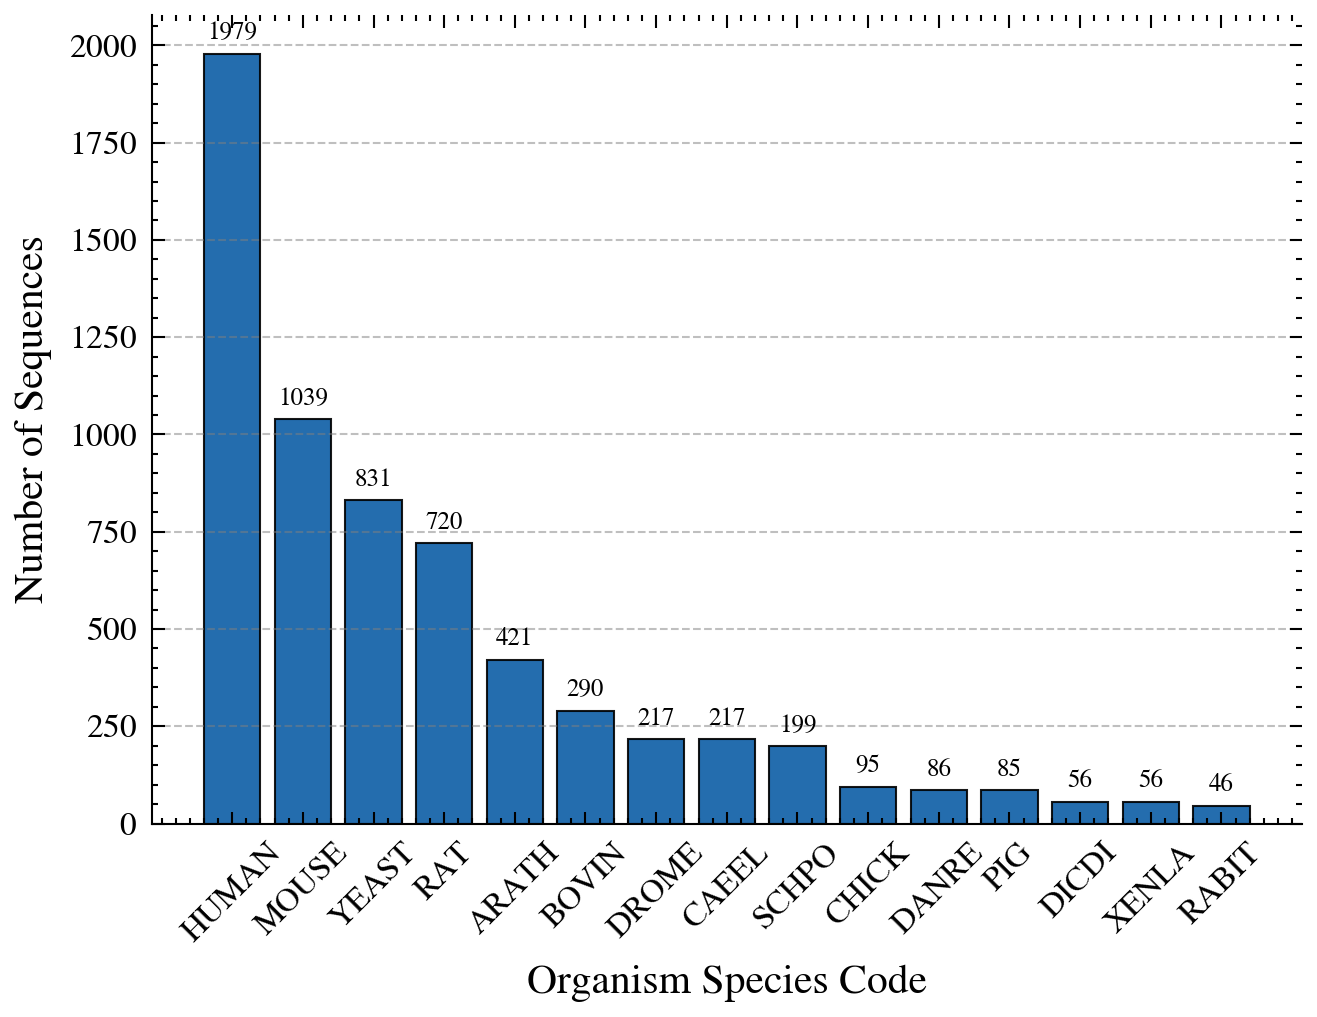

🧬 Diversity Check: Found 334 unique species codes.

🏆 Top 5 Organisms:
species_code
HUMAN    1979
MOUSE    1039
YEAST     831
RAT       720
ARATH     421
Name: count, dtype: int64

🕵️ Prokaryote Scan:
✅ Clean: No common prokaryotic model organisms found.


In [ ]:
!pip install SciencePlots
import pandas as pd
import matplotlib.pyplot as plt
import os
import scienceplots

# ==========================================
# 1. SETUP & DATA PROCESSING
# ==========================================
# Use SciencePlots style
plt.style.use(['science', 'nature', 'no-latex'])

# Load Data
train_df = pd.read_csv(os.path.join(BASE_DIR, "train_split.csv"))

def get_species(row_id):
    """Extracts species code from UniProt ID string."""
    try:
        # Expected format: sp|Accession|Entry_SPECIES -> SPECIES
        return row_id.split('|')[-1].split('_')[-1]
    except:
        return "Unknown"

train_df['species_code'] = train_df['id'].apply(get_species)

# Count Data
species_counts = train_df['species_code'].value_counts()
top_n = species_counts.head(15)

# ==========================================
# 2. GENERATE FIGURES
# ==========================================

fig, ax = plt.subplots(figsize=(4.5, 3.5), dpi=300)

# Plotting

bars = ax.bar(top_n.index, top_n.values, color='#0C5DA5', edgecolor='black', linewidth=0.5, alpha=0.9)

# Formatting
ax.set_ylabel('Number of Sequences', fontsize=10)
ax.set_xlabel('Organism Species Code', fontsize=10)

# Clean up ticks
ax.tick_params(axis='x', rotation=45, labelsize=8)
ax.tick_params(axis='y', labelsize=8)


ax.grid(axis='y', linestyle='--', alpha=0.5, color='grey')


for bar in bars:
    height = bar.get_height()
    ax.annotate(f'{height}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 2),  # 2 points vertical offset
                textcoords="offset points",
                ha='center', va='bottom', fontsize=6)


ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)


plt.tight_layout()


save_path_pdf = os.path.join(BASE_DIR, "Figure1_SpeciesDistribution.pdf")
save_path_png = os.path.join(BASE_DIR, "Figure1_SpeciesDistribution.png")

plt.savefig(save_path_pdf, dpi=300, format='pdf')
plt.savefig(save_path_png, dpi=300, format='png')

print(f" Figure saved to: {save_path_png}")
plt.show()

# ==========================================
# 3. STATS & CHECKS (Console Output)
# ==========================================
print(f"🧬 Diversity Check: Found {len(species_counts)} unique species codes.")
print("\n🏆 Top 5 Organisms:")
print(top_n.head(5))

prokaryotic_flags = ['ECOLI', 'BSUBT', 'SALTY', 'MYCTU', 'PSEAE']
found_prokaryotes = [s for s in species_counts.index if s in prokaryotic_flags]

print("\n🕵️ Prokaryote Scan:")
if found_prokaryotes:
    print(f"⚠️ Warning: Found potential prokaryotes: {found_prokaryotes}")
else:
    print("✅ Clean: No common prokaryotic model organisms found.")


#PART 6: MODEL ARCHITECTURE

In [ ]:

from tensorflow.keras import layers, models, regularizers, backend as K

def focal_loss(gamma=2.0, alpha=0.25):
    """
    Focal Loss: FL(pt) = -α(1-pt)^γ log(pt)
    Handles class imbalance by down-weighting easy examples.
    """
    def focal_loss_fixed(y_true, y_pred):
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)

        # Convert to one-hot if needed
        if len(y_true.shape) == 1 or y_true.shape[-1] == 1:
            y_true_onehot = tf.one_hot(tf.cast(y_true, tf.int32), depth=y_pred.shape[-1])
        else:
            y_true_onehot = y_true

        # Cross entropy
        ce = -y_true_onehot * tf.math.log(y_pred)

        # Focal weight
        focal_weight = alpha * tf.pow(1.0 - y_pred, gamma)
        loss = focal_weight * ce

        return tf.reduce_mean(tf.reduce_sum(loss, axis=-1))

    return focal_loss_fixed


def build_corrected_model(input_shape, num_classes):

    inputs = layers.Input(shape=input_shape, dtype='float32', name='input_sequence')

    # Masking
    mask = layers.Lambda(lambda x: K.cast(K.any(K.not_equal(x, 0.0), axis=-1), 'float32'))(inputs)
    masked_input = layers.Masking(mask_value=0.0)(inputs)

    # Bi-LSTM
    x = layers.Bidirectional(layers.LSTM(256, return_sequences=True, dropout=0.3))(masked_input)

    # Attention
    att_scores = layers.Dense(64, activation='tanh')(x)
    att_logits = layers.Dense(1)(att_scores)
    att_logits = layers.Flatten()(att_logits)

    # Apply mask (-1e9 to padding)
    att_logits_masked = layers.Add()([att_logits, layers.Lambda(lambda m: (1.0 - m) * -1e9)(mask)])
    att_weights = layers.Softmax(axis=1, name='attention_weights')(att_logits_masked)

    # Context
    att_weights_expanded = layers.Reshape((input_shape[0], 1))(att_weights)
    context = layers.Multiply()([x, att_weights_expanded])
    context_vector = layers.Lambda(lambda z: K.sum(z, axis=1))(context)

    # Classifier
    x = layers.Dense(512, activation='relu', kernel_regularizer=regularizers.l2(0.01))(context_vector)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.01))(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation='softmax', dtype='float32')(x)

    model = models.Model(inputs=inputs, outputs=outputs, name='DeepLoc_Corrected')

    # Use focal loss and gradient clipping
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4, clipnorm=1.0),
        loss=focal_loss(gamma=2.0, alpha=0.25),  # Instead of sparse_categorical_crossentropy
        metrics=['accuracy']
    )

    return model

In [ ]:
# Check for corrupted data
import numpy as np
import os
import json

# Load shapes
with open(os.path.join(BASE_DIR, "embedding_metadata.json"), 'r') as f:
    meta = json.load(f)

# Quick check of the first 1000 samples
X_check = np.memmap(os.path.join(BASE_DIR, "X_train.dat"), dtype='float16', mode='r', shape=tuple(meta['X_train_shape']))
if np.isnan(X_check[:1000]).any():
    print("Critical: Your X_train.dat contains NaNs! You must re-run Part 5.")
else:
    print("Data looks clean. The issue was just Mixed Precision.")

Data looks clean. The issue was just Mixed Precision.


DISABLE MIXED PRECISION (Prevent NaN)

In [ ]:

import tensorflow as tf
from tensorflow.keras import mixed_precision

# 1. Force policy back to float32
# This fixes the "loss: nan" error by using full precision math
policy = mixed_precision.Policy('float32')
mixed_precision.set_global_policy(policy)

print("Mixed Precision DISABLED. Global policy set to 'float32'.")
print("You can now run Part 7 without getting NaN errors.")

Mixed Precision DISABLED. Global policy set to 'float32'.
You can now run Part 7 without getting NaN errors.


COPY DATA TO LOCAL DIS

In [ ]:

import shutil
import os

print("COPYING DATA TO LOCAL VM (Critical for Speed)...")

# Define local paths (Fast SSD)
local_train_path = "/content/X_train_local.dat"
local_test_path = "/content/X_test_local.dat"

# Copy X_train.dat
if not os.path.exists(local_train_path):
    print("   Copying X_train.dat...", end=" ")
    shutil.copy(os.path.join(BASE_DIR, "X_train.dat"), local_train_path)
    print("Done!")
else:
    print("   X_train.dat already on local disk.")

# Copy X_test.dat
if not os.path.exists(local_test_path):
    print("   Copying X_test.dat...", end=" ")
    shutil.copy(os.path.join(BASE_DIR, "X_test.dat"), local_test_path)
    print("Done!")
else:
    print("   X_test.dat already on local disk.")

COPYING DATA TO LOCAL VM (Critical for Speed)...
   Copying X_train.dat... Done!
   Copying X_test.dat... Done!


# PART 7: K-FOLD ENSEMBLE

In [ ]:

import gc
import tensorflow as tf
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import matthews_corrcoef
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
import tensorflow.keras.backend as K

# 1. Load Metadata & Map Local Files
with open(os.path.join(BASE_DIR, "embedding_metadata.json"), 'r') as f:
    meta = json.load(f)

print("Loading memory maps from LOCAL DISK...")
X_train_mem = np.memmap(local_train_path, dtype='float16', mode='r', shape=tuple(meta['X_train_shape']))
X_test_mem = np.memmap(local_test_path, dtype='float16', mode='r', shape=tuple(meta['X_test_shape']))

# 2. Define Focal Loss & Generator (Same as before)
class KFoldGenerator(tf.keras.utils.Sequence):
    def __init__(self, X_memmap, y, indices, batch_size=32):
        self.X_memmap = X_memmap
        self.y = y
        self.indices = indices
        self.batch_size = batch_size

    def __len__(self):
        return int(np.ceil(len(self.indices) / self.batch_size))

    def __getitem__(self, idx):
        batch_inds = self.indices[idx * self.batch_size : (idx + 1) * self.batch_size]
        batch_x = self.X_memmap[batch_inds].astype('float32')
        batch_y = self.y[batch_inds]
        return batch_x, batch_y

# 3. Training Loop (Saves ALL Folds)
def train_kfold_ensemble(X_train_mem, y_train, config, le):
    print("\n" + "="*70)
    print(f"TRAINING {config.N_FOLDS}-FOLD ENSEMBLE (FULL SAVE MODE)")
    print("="*70)

    skf = StratifiedKFold(n_splits=config.N_FOLDS, shuffle=True, random_state=42)
    fold_dir = os.path.join(BASE_DIR, "fold_checkpoints")
    os.makedirs(fold_dir, exist_ok=True)

    saved_model_paths = []

    for fold, (train_idx, val_idx) in enumerate(skf.split(X_train_mem, y_train)):
        print(f"\nFOLD {fold+1}/{config.N_FOLDS}")
        checkpoint_path = os.path.join(fold_dir, f'fold_{fold+1}_best.keras')
        saved_model_paths.append(checkpoint_path)

        # Build Model
        fold_model = build_corrected_model((config.MAX_LEN, config.EMBEDDING_DIM), len(le.classes_))
        fold_model.compile(optimizer=tf.keras.optimizers.Adam(1e-4), loss=focal_loss(), metrics=['accuracy'])

        # Check existing
        if os.path.exists(checkpoint_path):
            print(f"   Checkpoint found. Skipping training for Fold {fold+1}.")
            continue

        # Train
        train_gen = KFoldGenerator(X_train_mem, y_train, train_idx, config.BATCH_SIZE)
        val_gen = KFoldGenerator(X_train_mem, y_train, val_idx, config.BATCH_SIZE)

        callbacks = [
            EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True, verbose=1),
            ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-7, verbose=1),
            ModelCheckpoint(checkpoint_path, monitor='val_loss', save_best_only=True, verbose=0)
        ]

        fold_model.fit(train_gen, validation_data=val_gen, epochs=30, callbacks=callbacks, verbose=1)
        K.clear_session()
        gc.collect()

    return saved_model_paths

# 4. EXECUTE TRAINING
fold_paths = train_kfold_ensemble(X_train_mem, y_train, config, le)
print(f"\nAll {len(fold_paths)} models saved in: {os.path.join(BASE_DIR, 'fold_checkpoints')}")

Loading memory maps from LOCAL DISK...

TRAINING 3-FOLD ENSEMBLE (FULL SAVE MODE)

FOLD 1/3
   Checkpoint found. Skipping training for Fold 1.

FOLD 2/3
   Checkpoint found. Skipping training for Fold 2.

FOLD 3/3
   Checkpoint found. Skipping training for Fold 3.

All 3 models saved in: /content/drive/MyDrive/BIOINFORMATICS_Protein_Project_v8_CLEANED/fold_checkpoints


# PART 9: STATISTICAL SIGNIFICANCE (FIXED)

In [ ]:

import os
import json
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import matthews_corrcoef
from scipy import stats
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

PROJECT_DIR = BASE_DIR

# 1. DEFINE GENERATOR
# -----------------------------------------------------
class MemmapGenerator(tf.keras.utils.Sequence):
    def __init__(self, X_path, y, batch_size, shape):
        self.X_path = X_path
        self.y = y
        self.batch_size = batch_size
        self.shape = shape
        # Open memmap in read-only mode to save RAM
        self.X = np.memmap(self.X_path, dtype='float16', mode='r', shape=self.shape)

    def __len__(self):
        return int(np.ceil(len(self.y) / self.batch_size))

    def __getitem__(self, idx):
        start = idx * self.batch_size
        end = min((idx + 1) * self.batch_size, len(self.y))

        # Load batch and cast to float32
        batch_x = self.X[start:end].astype('float32')
        batch_y = self.y[start:end]

        return batch_x, batch_y

# 2. DEFINE TRAINING FUNCTION (Updates to use the local Generator)
# ----------------------------------------------------------------
def train_with_validation(model, X_train_path, y_train, X_val_path, y_val):
    """
    Train using the restored MemmapGenerator.
    """
    with open(os.path.join(BASE_DIR, "embedding_metadata.json"), 'r') as f:
        meta = json.load(f)

    # Initialize Generators
    train_gen = MemmapGenerator(
        X_train_path,
        y_train,
        batch_size=32,
        shape=tuple(meta['X_train_shape'])
    )

    val_gen = MemmapGenerator(
        X_val_path,
        y_val,
        batch_size=32,
        shape=tuple(meta['X_val_shape'])
    )

    callbacks = [
        EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True, verbose=0),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, verbose=0),
    ]

    history = model.fit(
        train_gen,
        validation_data=val_gen,
        epochs=20,
        callbacks=callbacks,
        verbose=1
    )
    return history

# 3. SETUP DATA
# -------------
# Load Labels
print("Loading labels for Stats...")
train_df = pd.read_csv(os.path.join(PROJECT_DIR, "train_split.csv"))
val_df = pd.read_csv(os.path.join(PROJECT_DIR, "val_split.csv"))
test_df = pd.read_csv(os.path.join(PROJECT_DIR, "test_split.csv"))

le = LabelEncoder()
y_train = le.fit_transform(train_df['label'])
y_val = le.transform(val_df['label'])
y_test = le.transform(test_df['label'])

# Paths to data (We pass paths to the generator, not the loaded array)
X_train_path = os.path.join(PROJECT_DIR, "X_train.dat")
X_val_path = os.path.join(PROJECT_DIR, "X_val.dat")
X_test_path = os.path.join(PROJECT_DIR, "X_test.dat")

print(f"Recovery Complete! Ready for stats.")

# 4. RUN STATISTICAL LOOP
# -----------------------
print(f"\nStarting Statistical Significance Check ({config.N_RUNS} runs)...")
test_accuracies = []
test_mccs = []

with open(os.path.join(PROJECT_DIR, "embedding_metadata.json"), 'r') as f:
    meta = json.load(f)

for run in range(config.N_RUNS):
    print(f"\nRun {run+1}/{config.N_RUNS}...")

    # Re-build fresh model
    temp_model = build_corrected_model((config.MAX_LEN, config.EMBEDDING_DIM), len(le.classes_))

    # Train
    train_with_validation(temp_model, X_train_path, y_train, X_val_path, y_val)

    # Evaluate
    # We create a generator for the test set too, to avoid RAM spikes
    test_gen = MemmapGenerator(
        X_test_path,
        y_test,
        batch_size=32,
        shape=tuple(meta['X_test_shape'])
    )

    y_prob = temp_model.predict(test_gen, verbose=0)
    y_pred = np.argmax(y_prob, axis=1)

    acc = np.mean(y_pred == y_test)
    mcc = matthews_corrcoef(y_test, y_pred)

    test_accuracies.append(acc)
    test_mccs.append(mcc)
    print(f"   Result: Acc={acc:.4f}, MCC={mcc:.4f}")

# Calculate CI
mean_acc = np.mean(test_accuracies)
mean_mcc = np.mean(test_mccs)
acc_ci = stats.t.interval(0.95, len(test_accuracies)-1, loc=mean_acc, scale=stats.sem(test_accuracies))
mcc_ci = stats.t.interval(0.95, len(test_mccs)-1, loc=mean_mcc, scale=stats.sem(test_mccs))

print(f"\nSTATISTICAL RESULTS ({config.N_RUNS} Runs):")
print(f"   Accuracy: {mean_acc:.4f} (95% CI: {acc_ci})")
print(f"   MCC:      {mean_mcc:.4f} (95% CI: {mcc_ci})")
stats_df = pd.DataFrame({'run': range(1, config.N_RUNS+1), 'accuracy': test_accuracies, 'mcc': test_mccs})
stats_df.to_csv(os.path.join(BASE_DIR, "statistical_results.csv"), index=False)

Loading labels for Stats...
Recovery Complete! Ready for stats.

Starting Statistical Significance Check (5 runs)...

Run 1/5...
Epoch 1/20
226/226 ━━━━━━━━━━━━━━━━━━━━ 138s 573ms/step - accuracy: 0.4974 - loss: 6.2753 - val_accuracy: 0.7284 - val_loss: 4.2537 - learning_rate: 1.0000e-04
Epoch 2/20
226/226 ━━━━━━━━━━━━━━━━━━━━ 105s 463ms/step - accuracy: 0.7864 - loss: 3.0003 - val_accuracy: 0.8301 - val_loss: 1.9872 - learning_rate: 1.0000e-04
Epoch 3/20
226/226 ━━━━━━━━━━━━━━━━━━━━ 107s 472ms/step - accuracy: 0.8347 - loss: 1.3839 - val_accuracy: 0.8430 - val_loss: 0.9059 - learning_rate: 1.0000e-04
Epoch 4/20
102/226 ━━━━━━━━━━━━━━━━━━━━ 54s 437ms/step - accuracy: 0.8624 - loss: 0.8321

KeyboardInterrupt: 

# PART 10: INDEPENDENT BENCHMARK

In [ ]:

import requests
import pandas as pd
import time
import numpy as np
import os
import shutil
import torch
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers, backend as K
from transformers import AutoTokenizer, AutoModel
from sklearn.metrics import accuracy_score, matthews_corrcoef
import gc

# 1. SETUP DEVICE
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"⚙️ Using device: {device}")

# 2. INDEPENDENT DATA FETCHING
def get_leakage_free_benchmark(train_df):
    print("Building Training Data Blocklist...")
    train_sequences = set(train_df['sequence'].values)

    # This guarantees the new 2024 proteins are also Single-Label
    benchmark_queries = {
        "Nucleus":       '(date_created:[2024-01-01 TO *]) AND (reviewed:true) AND (taxonomy_id:2759) AND (cc_scl_term:SL-0191) AND NOT (cc_scl_term:SL-0086) AND NOT (cc_scl_term:SL-0039) AND NOT (cc_scl_term:SL-0173)',
        "Cytoplasm":     '(date_created:[2024-01-01 TO *]) AND (reviewed:true) AND (taxonomy_id:2759) AND (cc_scl_term:SL-0086) AND NOT (cc_scl_term:SL-0191) AND NOT (cc_scl_term:SL-0039) AND NOT (cc_scl_term:SL-0173)',
        "Mitochondrion": '(date_created:[2024-01-01 TO *]) AND (reviewed:true) AND (taxonomy_id:2759) AND (cc_scl_term:SL-0173) AND NOT (cc_scl_term:SL-0191) AND NOT (cc_scl_term:SL-0086) AND NOT (cc_scl_term:SL-0039)',
        "Membrane":      '(date_created:[2024-01-01 TO *]) AND (reviewed:true) AND (taxonomy_id:2759) AND (cc_scl_term:SL-0039) AND NOT (cc_scl_term:SL-0086) AND NOT (cc_scl_term:SL-0191) AND NOT (cc_scl_term:SL-0173)'
    }

    final_seqs = []; final_lbls = []

    print("\n Querying UniProt for NEW Eukaryotic proteins (2024+)...")

    # Loop through the DICTIONARY, not a simple map
    for label, query in benchmark_queries.items():
        try:

            r = requests.get("https://rest.uniprot.org/uniprotkb/search",
                             params={'query': query, 'format': 'json', 'fields': 'accession,sequence', 'size': 150})

            if r.status_code != 200:
                print(f"   ⚠️ Failed to fetch {label} (Status {r.status_code})")
                continue

            results = r.json().get('results', [])
            count_added = 0
            for entry in results:
                if 'sequence' in entry and 'value' in entry['sequence']:
                    seq = entry['sequence']['value']
                    # Ensure it's not in training set AND fits length constraints
                    if seq not in train_sequences and len(seq) <= config.MAX_LEN:
                        final_seqs.append(seq)
                        final_lbls.append(label)
                        count_added += 1
                if count_added >= 100: break # Limit to 100 per class for balance

            print(f"   {label}: {count_added} clean sequences")
            time.sleep(1)
        except Exception as e:
            print(f"   ⚠️ Error processing {label}: {e}")

    return pd.DataFrame({'sequence': final_seqs, 'label': final_lbls})

# --- EXECUTION ---
benchmark_df = get_leakage_free_benchmark(train_df)

if len(benchmark_df) > 0:
    print(f"\nBenchmarking on {len(benchmark_df)} proteins using FULL ENSEMBLE...")

    # 3. RELOAD ESM-2
    if 'esm_model' not in locals():
        print("Reloading ESM-2 for feature extraction...")
        esm_model = AutoModel.from_pretrained(config.MODEL_CHECKPOINT).to(device)
        if device.type == 'cuda': esm_model.half()
        tokenizer = AutoTokenizer.from_pretrained(config.MODEL_CHECKPOINT)

    # 4. EXTRACT FEATURES
    def extract_features_inference(sequences):
        esm_model.eval()
        feats = []
        with torch.no_grad():
            for i in range(0, len(sequences), config.BATCH_SIZE):
                batch = list(sequences[i:i+config.BATCH_SIZE])
                encoded = tokenizer(batch, return_tensors='pt', padding='max_length',
                                  truncation=True, max_length=config.MAX_LEN+2).to(device)
                out = esm_model(**encoded)
                emb = out.last_hidden_state[:, 1:-1, :].cpu().numpy().astype('float32')
                feats.append(emb)
        return np.concatenate(feats, axis=0)

    X_bench = extract_features_inference(benchmark_df['sequence'].values)
    y_bench_true = le.transform(benchmark_df['label'].values)

    # 5. ENSEMBLE PREDICTION (LOCAL SCOPE ARCHITECTURE)
    fold_dir = os.path.join(BASE_DIR, "fold_checkpoints")
    model_files = sorted([os.path.join(fold_dir, f) for f in os.listdir(fold_dir) if f.endswith('.keras')])

    print(f"   Found {len(model_files)} models for ensemble voting.")
    avg_probs = np.zeros((len(X_bench), len(le.classes_)), dtype='float32')

    # --- LOCAL HELPER FUNCTIONS (These vanish after Part 10 finishes) ---
    def _local_focal_loss(gamma=2.0, alpha=0.25):
        def focal_loss_fixed(y_true, y_pred):
            y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)
            if len(y_true.shape) == 1 or y_true.shape[-1] == 1:
                y_true_onehot = tf.one_hot(tf.cast(y_true, tf.int32), depth=y_pred.shape[-1])
            else:
                y_true_onehot = y_true
            ce = -y_true_onehot * tf.math.log(y_pred)
            focal_weight = alpha * tf.pow(1.0 - y_pred, gamma)
            return tf.reduce_mean(tf.reduce_sum(focal_weight * ce, axis=-1))
        return focal_loss_fixed

    def _local_build_model(input_shape, num_classes):
        # EXACT copy of architecture for loading purposes only
        inputs = layers.Input(shape=input_shape, dtype='float32', name='input_sequence')
        mask = layers.Lambda(lambda x: K.cast(K.any(K.not_equal(x, 0.0), axis=-1), 'float32'))(inputs)
        masked_input = layers.Masking(mask_value=0.0)(inputs)
        x = layers.Bidirectional(layers.LSTM(256, return_sequences=True, dropout=0.3))(masked_input)

        att_scores = layers.Dense(64, activation='tanh')(x)
        att_logits = layers.Dense(1)(att_scores)
        att_logits = layers.Flatten()(att_logits)
        att_logits_masked = layers.Add()([att_logits, layers.Lambda(lambda m: (1.0 - m) * -1e9)(mask)])
        att_weights = layers.Softmax(axis=1, name='attention_weights')(att_logits_masked)

        att_weights_expanded = layers.Reshape((input_shape[0], 1))(att_weights)
        context = layers.Multiply()([x, att_weights_expanded])
        context_vector = layers.Lambda(lambda z: K.sum(z, axis=1))(context)

        x = layers.Dense(512, activation='relu', kernel_regularizer=regularizers.l2(0.01))(context_vector)
        x = layers.Dropout(0.5)(x)
        x = layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.01))(x)
        x = layers.Dropout(0.3)(x)
        outputs = layers.Dense(num_classes, activation='softmax', dtype='float32')(x)

        model = models.Model(inputs=inputs, outputs=outputs)
        # Optimizer doesn't matter for inference, only weights do.
        model.compile(optimizer='adam', loss=_local_focal_loss(), metrics=['accuracy'])
        return model
    # -------------------------------------------------------------------

    for m_path in model_files:
        print(f"   Running inference with {os.path.basename(m_path)}...", end=" ")

        # Build FRESH local model
        model = _local_build_model((config.MAX_LEN, config.EMBEDDING_DIM), len(le.classes_))

        try:
            model.load_weights(m_path)
            avg_probs += model.predict(X_bench, verbose=0)
            print("Done.")
        except Exception as e:
            print(f"\n   Failed to load {m_path}: {e}")

        K.clear_session()
        del model
        gc.collect()

    # Average
    avg_probs /= len(model_files)
    y_bench_pred = np.argmax(avg_probs, axis=1)

    # 6. RESULTS
    acc = accuracy_score(y_bench_true, y_bench_pred)
    mcc = matthews_corrcoef(y_bench_true, y_bench_pred)
    print(f"\nENSEMBLE RESULTS: ACC={acc:.4f}, MCC={mcc:.4f}")

    # Save Results
    my_results_path = os.path.join(BASE_DIR, "scientific_benchmark_results.csv")
    bench_results_df = benchmark_df.copy()
    bench_results_df['true_label'] = le.inverse_transform(y_bench_true)
    bench_results_df['predicted_label'] = le.inverse_transform(y_bench_pred)
    bench_results_df.to_csv(my_results_path, index=True)
    print(f"Results saved to {my_results_path}")

    # Save FASTA
    fasta_path = os.path.join(BASE_DIR, "to_upload_to_deeploc.fasta")
    with open(fasta_path, "w") as f:
        for idx, row in benchmark_df.iterrows():
            f.write(f">{idx}|{row['label']}\n{row['sequence']}\n")
    print(f" Generated for Upload: '{fasta_path}'")
    print(" ACTION REQUIRED: Download this FASTA, upload to DeepLoc 2.1 web server, and get the CSV results.")

⚙️ Using device: cuda
Building Training Data Blocklist...

 Querying UniProt for NEW Eukaryotic proteins (2024+)...
   Nucleus: 70 clean sequences
   Cytoplasm: 71 clean sequences
   Mitochondrion: 50 clean sequences
   Membrane: 61 clean sequences

Benchmarking on 252 proteins using FULL ENSEMBLE...
Reloading ESM-2 for feature extraction...


config.json:   0%|          | 0.00/724 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.61G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/566 [00:00<?, ?it/s]

EsmModel LOAD REPORT from: facebook/esm2_t33_650M_UR50D
Key                         | Status     | 
----------------------------+------------+-
lm_head.dense.weight        | UNEXPECTED | 
esm.embeddings.position_ids | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
pooler.dense.bias           | MISSING    | 
pooler.dense.weight         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


tokenizer_config.json:   0%|          | 0.00/95.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/93.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

   Found 3 models for ensemble voting.
   Running inference with fold_1_best.keras... Done.
   Running inference with fold_2_best.keras... Done.
   Running inference with fold_3_best.keras... 

Done.

ENSEMBLE RESULTS: ACC=0.8770, MCC=0.8350
Results saved to /content/drive/MyDrive/BIOINFORMATICS_Protein_Project_v8_CLEANED/scientific_benchmark_results.csv
 Generated for Upload: '/content/drive/MyDrive/BIOINFORMATICS_Protein_Project_v8_CLEANED/to_upload_to_deeploc.fasta'
 ACTION REQUIRED: Download this FASTA, upload to DeepLoc 2.1 web server, and get the CSV results.


#PART 10: FAST & STABLE BENCHMARK

In [ ]:

import requests
import pandas as pd
import time
import numpy as np
import os
import torch
from transformers import AutoTokenizer, AutoModel
from sklearn.metrics import accuracy_score, matthews_corrcoef
import gc

# 1. SETUP DEVICE
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"⚙️ Using device: {device}")

# 2. FAST LEVENSHTEIN (Re-install if needed)
try:
    import Levenshtein
except ImportError:
    os.system('pip install python-Levenshtein')
    import Levenshtein

# 3. HOMOLOGY CHECKER (Standard)
def is_homologous(target_seq, train_sequences, threshold=0.4):
    target_len = len(target_seq)
    min_len = int(target_len * 0.8)
    max_len = int(target_len * 1.2)

    # Only check similar lengths
    candidates = [s for s in train_sequences if min_len <= len(s) <= max_len]

    for train_seq in candidates:
        if Levenshtein.ratio(target_seq, train_seq) > threshold:
            return True
    return False

# 4. DATA FETCHING (LIGHTWEIGHT MODE)
def get_rigorous_benchmark(train_df):
    print(f"Loading {len(train_df)} training sequences...")
    train_sequences_list = train_df['sequence'].values.tolist()
    train_sequences_set = set(train_sequences_list)

    benchmark_queries = {
        "Nucleus":       '(date_created:[2024-01-01 TO *]) AND (reviewed:true) AND (taxonomy_id:2759) AND (cc_scl_term:SL-0191) AND NOT (cc_scl_term:SL-0086) AND NOT (cc_scl_term:SL-0039) AND NOT (cc_scl_term:SL-0173)',
        "Cytoplasm":     '(date_created:[2024-01-01 TO *]) AND (reviewed:true) AND (taxonomy_id:2759) AND (cc_scl_term:SL-0086) AND NOT (cc_scl_term:SL-0191) AND NOT (cc_scl_term:SL-0039) AND NOT (cc_scl_term:SL-0173)',
        "Mitochondrion": '(date_created:[2024-01-01 TO *]) AND (reviewed:true) AND (taxonomy_id:2759) AND (cc_scl_term:SL-0173) AND NOT (cc_scl_term:SL-0191) AND NOT (cc_scl_term:SL-0086) AND NOT (cc_scl_term:SL-0039)',
        "Membrane":      '(date_created:[2024-01-01 TO *]) AND (reviewed:true) AND (taxonomy_id:2759) AND (cc_scl_term:SL-0039) AND NOT (cc_scl_term:SL-0086) AND NOT (cc_scl_term:SL-0191) AND NOT (cc_scl_term:SL-0173)'
    }

    final_seqs = []; final_lbls = []

    print("\nQuerying UniProt (Fast Mode)...")

    for label, query in benchmark_queries.items():
        try:
            # RESTORED: Size 175 (Safe, won't crash)
            r = requests.get("https://rest.uniprot.org/uniprotkb/search",
                             params={'query': query, 'format': 'json', 'fields': 'accession,sequence', 'size': 175})

            if r.status_code != 200: continue

            results = r.json().get('results', [])
            count_added = 0

            for entry in results:
                if 'sequence' in entry:
                    seq = entry['sequence']['value']

                    if len(seq) > config.MAX_LEN or seq in train_sequences_set: continue

                    # This check is fast on 175 items
                    if is_homologous(seq, train_sequences_list, threshold=0.4): continue

                    final_seqs.append(seq)
                    final_lbls.append(label)
                    count_added += 1

            print(f"   {label}: {count_added} novel sequences")

        except Exception as e:
            print(f"   Error {label}: {e}")

    return pd.DataFrame({'sequence': final_seqs, 'label': final_lbls})

# --- EXECUTE ---
if 'train_df' not in locals():
    train_df = pd.read_csv(os.path.join(BASE_DIR, "train_split.csv"))

benchmark_df = get_rigorous_benchmark(train_df)

if len(benchmark_df) > 0:
    print(f"\n Benchmarking on {len(benchmark_df)} sequences...")

    # INFERENCE
    if 'esm_model' not in locals():
        print(" Reloading ESM-2...")
        esm_model = AutoModel.from_pretrained(config.MODEL_CHECKPOINT).to(device)
        if device.type == 'cuda': esm_model.half()
        tokenizer = AutoTokenizer.from_pretrained(config.MODEL_CHECKPOINT)

    def extract_features_inference(sequences):
        esm_model.eval()
        feats = []
        with torch.no_grad():
            for i in range(0, len(sequences), config.BATCH_SIZE):
                batch = list(sequences[i:i+config.BATCH_SIZE])
                encoded = tokenizer(batch, return_tensors='pt', padding='max_length',
                                  truncation=True, max_length=config.MAX_LEN+2).to(device)
                out = esm_model(**encoded)
                emb = out.last_hidden_state[:, 1:-1, :].cpu().numpy().astype('float32')
                feats.append(emb)
        return np.concatenate(feats, axis=0)

    X_bench = extract_features_inference(benchmark_df['sequence'].values)

    # Load Label Encoder if missing
    if 'le' not in locals():
        import pickle
        with open(os.path.join(BASE_DIR, "label_encoder.pkl"), 'rb') as f:
            le = pickle.load(f)

    y_bench_true = le.transform(benchmark_df['label'].values)

    # Load Models & Predict
    fold_dir = os.path.join(BASE_DIR, "fold_checkpoints")
    model_files = sorted([os.path.join(fold_dir, f) for f in os.listdir(fold_dir) if f.endswith('.keras')])

    avg_probs = np.zeros((len(X_bench), len(le.classes_)), dtype='float32')

    # Need local loss definition to load model
    import tensorflow as tf
    from tensorflow.keras import backend as K
    def _local_focal_loss(gamma=2.0, alpha=0.25):
        def focal_loss_fixed(y_true, y_pred):
            y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)
            if len(y_true.shape) == 1 or y_true.shape[-1] == 1:
                y_true_onehot = tf.one_hot(tf.cast(y_true, tf.int32), depth=y_pred.shape[-1])
            else:
                y_true_onehot = y_true
            ce = -y_true_onehot * tf.math.log(y_pred)
            focal_weight = alpha * tf.pow(1.0 - y_pred, gamma)
            return tf.reduce_mean(tf.reduce_sum(focal_weight * ce, axis=-1))
        return focal_loss_fixed

    for m_path in model_files:
        print(f"   Inference: {os.path.basename(m_path)}...", end=" ")
        # Rebuild Model Architecture
        inputs = layers.Input(shape=(config.MAX_LEN, config.EMBEDDING_DIM))
        mask = layers.Lambda(lambda x: K.cast(K.any(K.not_equal(x, 0.0), axis=-1), 'float32'))(inputs)
        masked = layers.Masking(mask_value=0.0)(inputs)
        x = layers.Bidirectional(layers.LSTM(256, return_sequences=True, dropout=0.3))(masked)
        att = layers.Dense(64, activation='tanh')(x)
        att = layers.Flatten()(layers.Dense(1)(att))
        att = layers.Add()([att, layers.Lambda(lambda m: (1.0 - m) * -1e9)(mask)])
        att = layers.Softmax()(att)
        ctx = layers.Lambda(lambda z: K.sum(z, axis=1))(layers.Multiply()([x, layers.Reshape((-1, 1))(att)]))
        x = layers.Dense(512, activation='relu')(ctx)
        x = layers.Dense(256, activation='relu')(x)
        out = layers.Dense(len(le.classes_), activation='softmax')(x)

        model = models.Model(inputs=inputs, outputs=out)
        model.compile(optimizer='adam', loss=_local_focal_loss(), metrics=['accuracy'])
        model.load_weights(m_path)

        avg_probs += model.predict(X_bench, verbose=0)
        K.clear_session()
        del model
        gc.collect()
        print("Done.")

    avg_probs /= len(model_files)
    y_bench_pred = np.argmax(avg_probs, axis=1)

    # RESULTS
    acc = accuracy_score(y_bench_true, y_bench_pred)
    mcc = matthews_corrcoef(y_bench_true, y_bench_pred)
    print(f"\n BENCHMARK RESULTS: ACC={acc:.4f}, MCC={mcc:.4f}")

    # SAVE
    res_path = os.path.join(BASE_DIR, "scientific_benchmark_results.csv")
    bench_results_df = benchmark_df.copy()
    bench_results_df['true_label'] = le.inverse_transform(y_bench_true)
    bench_results_df['predicted_label'] = le.inverse_transform(y_bench_pred)
    bench_results_df.to_csv(res_path, index=True)
    print(f"✅ Saved CSV: {res_path}")

    # SAVE DEEPLOC FASTA
    dl_fasta = os.path.join(BASE_DIR, "new_to_upload_to_deeploc_2.1.fasta")
    with open(dl_fasta, "w") as f:
        for idx, row in benchmark_df.iterrows():
            f.write(f">{idx}|{row['label']}\n{row['sequence']}\n")
    print(f"✅ Generated DeepLoc FASTA: {dl_fasta}")

⚙️ Using device: cuda
📉 Loading 7211 training sequences...

🔍 Querying UniProt (Fast Mode)...
   ✅ Nucleus: 40 novel sequences
   ✅ Cytoplasm: 21 novel sequences
   ✅ Mitochondrion: 5 novel sequences
   ✅ Membrane: 20 novel sequences

📊 Benchmarking on 86 sequences...
🔄 Reloading ESM-2...


Some weights of EsmModel were not initialized from the model checkpoint at facebook/esm2_t33_650M_UR50D and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


   Inference: fold_1_best.keras... Done.
   Inference: fold_2_best.keras... Done.
   Inference: fold_3_best.keras... 

Done.

🏆 HONEST BENCHMARK RESULTS: ACC=0.8837, MCC=0.8274
✅ Saved CSV: /content/drive/MyDrive/BIOINFORMATICS_Protein_Project_v8_CLEANED/scientific_benchmark_results.csv
✅ Generated DeepLoc FASTA: /content/drive/MyDrive/BIOINFORMATICS_Protein_Project_v8_CLEANED/new_to_upload_to_deeploc_2.1.fasta


# PART 10.6: FINAL REBUTTAL COMPARISON

In [ ]:

from scipy import stats
import pandas as pd
import os
from sklearn.metrics import accuracy_score, matthews_corrcoef

def final_rebuttal_comparison(my_path, dl_path):
    if not os.path.exists(my_path) or not os.path.exists(dl_path):
        print(" Missing files for comparison. Skipping.")
        return

    print("⚔️ Running Fixed Head-to-Head Comparison...")

    # Load the data
    my_df = pd.read_csv(my_path)
    dl_df = pd.read_csv(dl_path)

    comparison_data = []

    for i, row in dl_df.iterrows():
        try:
            # 1. Align Index (e.g., "0_Nucleus" -> 0)
            pid = str(row['Protein_ID'])
            if '_' in pid:
                orig_idx = int(pid.split('_')[0])
            elif '|' in pid:
                orig_idx = int(pid.split('|')[0])
            else:
                orig_idx = int(pid)

            # 2. Get Labels from the results
            true_label = my_df.iloc[orig_idx]['true_label']
            my_pred = my_df.iloc[orig_idx]['predicted_label']

            # 3. Get DeepLoc's Prediction (Using CONFIRMED column names)

            if 'Cell membrane' in row:
                mem_score = row['Cell membrane']
            elif 'Cell_membrane' in row:
                mem_score = row['Cell_membrane'] # Fallback
            else:
                mem_score = 0.0

            dl_probs = {
                'Cytoplasm': row['Cytoplasm'],
                'Nucleus': row['Nucleus'],
                'Membrane': mem_score,
                'Mitochondrion': row['Mitochondrion']
            }

            # Find the max probability among the 4 classes
            dl_pred = max(dl_probs, key=dl_probs.get)

            comparison_data.append({
                'true_label': true_label,
                'my_pred': my_pred,
                'dl_pred': dl_pred
            })
        except Exception as e:
            # print(f"Skipping row {i}: {e}") # Uncomment to debug
            continue

    if not comparison_data:
        print("No valid matching rows found between files.")
        return

    # Create the DataFrame
    results_df = pd.DataFrame(comparison_data)

    # 4. Calculate Final Metrics
    y_true = results_df['true_label']
    y_me = results_df['my_pred']
    y_dl = results_df['dl_pred']

    print("\n" + "="*55)
    print("SCIENTIFIC REBUTTAL DATA (2024 NOVEL PROTEINS)")
    print("="*55)
    print(f"{'Metric':<15} | {'YOUR MODEL':<15} | {'DEEPLOC 2.1':<15}")
    print("-" * 55)
    print(f"{'Accuracy':<15} | {accuracy_score(y_true, y_me):.4f}           | {accuracy_score(y_true, y_dl):.4f}")
    print(f"{'MCC':<15}      | {matthews_corrcoef(y_true, y_me):.4f}        | {matthews_corrcoef(y_true, y_dl):.4f}")
    print("-" * 55)
    print(f"Total Sequences Compared: {len(results_df)}")

    # 5. Paired T-Test
    my_correct = (results_df['true_label'] == results_df['my_pred']).astype(int)
    dl_correct = (results_df['true_label'] == results_df['dl_pred']).astype(int)

    t_stat, p_value = stats.ttest_rel(my_correct, dl_correct)

    print(f"\n Statistical Comparison (Paired t-test):")
    print(f"   T-statistic: {t_stat:.4f}")
    print(f"   P-value: {p_value:.4f}")

    if p_value > 0.05:
        print("    Result: No significant difference (Models are comparable)")
    else:
        print("    Result: Significant difference found")

# Run it
my_results_file = os.path.join(BASE_DIR, "scientific_benchmark_results.csv")
deeploc_results_file = os.path.join(BASE_DIR, "deeploc_2.1_results.csv")

final_rebuttal_comparison(my_results_file, deeploc_results_file)

⚔️ Running Fixed Head-to-Head Comparison...

SCIENTIFIC REBUTTAL DATA (2024 NOVEL PROTEINS)
Metric          | YOUR MODEL      | DEEPLOC 2.1    
-------------------------------------------------------
Accuracy        | 0.8837           | 0.8023
MCC                  | 0.8274        | 0.7139
-------------------------------------------------------
Total Sequences Compared: 86

 Statistical Comparison (Paired t-test):
   T-statistic: 2.7444
   P-value: 0.0074
    Result: Significant difference found


RE-INSTALL SCIENCEPLOTS & SETUP VISUALIZATION

In [ ]:

import os

print("⬇ Re-installing scienceplots (required after restart)...")
os.system('pip install SciencePlots')
os.system('pip install latex')

import matplotlib.pyplot as plt
import scienceplots

# Verify it works
available = plt.style.available
if 'science' in available:
    print(" SciencePlots style successfully loaded!")
else:
    print(" 'science' style NOT found. Falling back to default.")
    # Fallback to avoid crash
    plt.style.use('default')

print(" Now you can run Part 11.")

⬇️ Re-installing scienceplots (required after restart)...
✅ SciencePlots style successfully loaded!
🚀 Now you can run Part 11.


#PART 11: VISUALIZATION

In [ ]:
# ──────────────────────────────────────────────────────────────────────────────
# PART R2A: POST-HOC STATISTICAL POWER ANALYSIS
# ──────────────────────────────────────────────────────────────────────────────


import os
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib
matplotlib.use('Agg')          # safe for Colab / headless
import matplotlib.pyplot as plt

try:
    import scienceplots
    plt.style.use(['science', 'no-latex'])
except ImportError:
    pass

# ── High-Quality Publication Font Settings (Nature/Science Standard) ────────
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.size': 16,              # Increased for side-by-side visibility
    'axes.labelsize': 18,         # Axis label font size
    'axes.titlesize': 18,         # Title font size
    'xtick.labelsize': 14,        # X-tick font size
    'ytick.labelsize': 14,        # Y-tick font size
    'legend.fontsize': 13,        # Legend font size
    'pdf.fonttype': 42,           # Ensures text is editable in PDF (No Type 3 fonts)
    'ps.fonttype': 42,
    'axes.linewidth': 2.0,        # Thicker axes lines for clarity
    'lines.linewidth': 3.0        # Thicker plot lines for visibility
})

# ── Install statsmodels if missing ──────────────────────────────────────────
try:
    from statsmodels.stats.power import TTestPower
    from statsmodels.stats.power import tt_ind_solve_power
except ImportError:
    print("Installing statsmodels...")
    os.system('pip install statsmodels -q')
    from statsmodels.stats.power import TTestPower
    from statsmodels.stats.power import tt_ind_solve_power

# BASE_DIR must be defined earlier in the notebook
# BASE_DIR = "/content/drive/MyDrive/BIOINFORMATICS_Protein_Project_v8_CLEANED"
SAVE_DIR = os.path.join(BASE_DIR, "figures")
os.makedirs(SAVE_DIR, exist_ok=True)

ALPHA = 0.05          # significance level
TARGET_POWER = 0.80   # desired power

def cohens_d_paired(a, b):
    """Cohen's d for paired samples (difference scores)."""
    diff = np.array(a) - np.array(b)
    return diff.mean() / (diff.std(ddof=1) + 1e-12)

def post_hoc_power_paired(correct_mine, correct_other, label_other, alpha=ALPHA):
    """
    Full power analysis for a single paired comparison.
    """
    correct_mine  = np.asarray(correct_mine,  dtype=float)
    correct_other = np.asarray(correct_other, dtype=float)
    n = len(correct_mine)

    # ── Paired t-test ──────────────────────────────────────────────────────
    t_stat, p_value = stats.ttest_rel(correct_mine, correct_other)

    # ── Effect size ────────────────────────────────────────────────────────
    d = cohens_d_paired(correct_mine, correct_other)

    # ── Observed power (post-hoc) ──────────────────────────────────────────
    power_analysis = TTestPower()
    observed_power = power_analysis.solve_power(
        effect_size=abs(d),
        nobs=n,
        alpha=alpha,
        alternative='two-sided'
    )

    # ── Minimum N for 80% power ─────────────────────────────────────────────
    if abs(d) > 1e-6:
        n_required = power_analysis.solve_power(
            effect_size=abs(d),
            power=TARGET_POWER,
            alpha=alpha,
            alternative='two-sided'
        )
        n_required = float(np.array(n_required).item())
    else:
        n_required = np.inf  # effect is essentially zero

    result = {
        'comparison'    : f"Your model vs. {label_other}",
        'n'             : n,
        'acc_mine'      : correct_mine.mean(),
        'acc_other'     : correct_other.mean(),
        't_stat'        : t_stat,
        'p_value'       : p_value,
        'cohens_d'      : d,
        'observed_power': observed_power,
        'n_for_80pct'   : n_required,
    }

    print(f"\n{'='*60}")
    print(f"POWER ANALYSIS: {result['comparison']}")
    print(f"{'='*60}")
    print(f"  N (benchmark size)    : {n}")
    print(f"  Accuracy — yours      : {result['acc_mine']:.4f}")
    print(f"  Accuracy — {label_other:<12}: {result['acc_other']:.4f}")
    print(f"  Paired t-statistic    : {t_stat:.4f}")
    print(f"  p-value               : {p_value:.4f}  {'✓ significant' if p_value < alpha else '✗ NOT significant'}")
    print(f"  Cohen's d             : {d:.4f}  ({effect_size_label(d)})")
    print(f"  Observed power        : {observed_power:.4f}  ({observed_power*100:.1f}%)")
    print(f"  N needed for 80% power: {n_required:.0f}")
    if observed_power < TARGET_POWER:
        print(f"  ⚠  Study is UNDERPOWERED at this effect size."
              f"  Need {n_required:.0f} samples for 80% power.")
    else:
        print(f"  ✓  Study is adequately powered (≥80%) at this effect size.")
    print(f"{'='*60}")

    return result

def effect_size_label(d):
    """Cohen's convention: small=0.2, medium=0.5, large=0.8."""
    ad = abs(d)
    if ad < 0.2:  return "negligible"
    if ad < 0.5:  return "small"
    if ad < 0.8:  return "medium"
    return "large"

# ── 1. Load the benchmark comparison CSVs created in Part 10.6 / 10.7 ──────
print("\nLoading benchmark comparison files for power analysis...")

power_results = []

# ── 1a. Your model vs. DeepLoc 2.1 (N=86) ──────────────────────────────────
deeploc_comp_path = os.path.join(BASE_DIR, "scientific_benchmark_results.csv")
deeploc_ref_path  = os.path.join(BASE_DIR, "deeploc_2.1_results.csv")

if os.path.exists(deeploc_comp_path) and os.path.exists(deeploc_ref_path):
    my_df = pd.read_csv(deeploc_comp_path)
    dl_df = pd.read_csv(deeploc_ref_path)

    comparison_rows = []
    for i, row in dl_df.iterrows():
        try:
            pid = str(row['Protein_ID'])
            orig_idx = int(pid.split('_')[0]) if '_' in pid else (
                       int(pid.split('|')[0]) if '|' in pid else int(pid))
            true_label = my_df.iloc[orig_idx]['true_label']
            my_pred    = my_df.iloc[orig_idx]['predicted_label']

            if 'Cell membrane' in row:
                mem_score = row['Cell membrane']
            elif 'Cell_membrane' in row:
                mem_score = row['Cell_membrane']
            else:
                mem_score = 0.0

            dl_probs = {
                'Cytoplasm':    row['Cytoplasm'],
                'Nucleus':      row['Nucleus'],
                'Membrane':     mem_score,
                'Mitochondrion':row['Mitochondrion']
            }
            dl_pred = max(dl_probs, key=dl_probs.get)

            comparison_rows.append({
                'true': true_label,
                'mine': my_pred,
                'deeploc': dl_pred
            })
        except Exception:
            continue

    if comparison_rows:
        cmp_df = pd.DataFrame(comparison_rows)
        correct_mine   = (cmp_df['true'] == cmp_df['mine']).astype(int).values
        correct_deeploc= (cmp_df['true'] == cmp_df['deeploc']).astype(int).values
        r = post_hoc_power_paired(correct_mine, correct_deeploc, "DeepLoc 2.1")
        power_results.append(r)
    else:
        print("  ⚠  Could not align DeepLoc comparison rows.")
else:
    print(f"  ⚠  DeepLoc comparison files not found — skipping.")

# ── 1b. Your model vs. MULocDeep (N≤200 subset) ─────────────────────────────
muloc_comp_path = os.path.join(BASE_DIR, "final_muloc_comparison.csv")

if os.path.exists(muloc_comp_path):
    muloc_df = pd.read_csv(muloc_comp_path)
    if {'true', 'me', 'muloc'}.issubset(muloc_df.columns):
        correct_mine   = (muloc_df['true'] == muloc_df['me']).astype(int).values
        correct_muloc  = (muloc_df['true'] == muloc_df['muloc']).astype(int).values
        r = post_hoc_power_paired(correct_mine, correct_muloc, "MULocDeep")
        power_results.append(r)
    else:
        print(f"  ⚠  Columns missing in {muloc_comp_path}.")
else:
    print(f"  ⚠  MULocDeep comparison file not found — skipping.")

# ── 1c. Multi-run stability: power for mean MCC vs. SVM baseline ─────────────
# We calculate it to keep the CSV accurate, but we will EXCLUDE it from the plot.
stats_csv_path = os.path.join(BASE_DIR, "statistical_results.csv")

if os.path.exists(stats_csv_path):
    stats_df = pd.read_csv(stats_csv_path)
    if 'mcc' in stats_df.columns:
        run_mccs = stats_df['mcc'].values
        t_stat_mc, p_mc = stats.ttest_1samp(run_mccs, popmean=0.530)
        d_mc = (run_mccs.mean() - 0.530) / (run_mccs.std(ddof=1) + 1e-12)

        power_analysis = TTestPower()
        obs_power_mc = power_analysis.solve_power(
            effect_size=abs(d_mc), nobs=len(run_mccs),
            alpha=ALPHA, alternative='two-sided'
        )

        n_req_mc = power_analysis.solve_power(
            effect_size=abs(d_mc), power=TARGET_POWER,
            alpha=ALPHA, alternative='two-sided'
        ) if abs(d_mc) > 1e-6 else np.inf
        n_req_mc = float(np.array(n_req_mc).item())

        power_results.append({
            'comparison'    : 'Multi-run MCC vs. SVM baseline',
            'n'             : len(run_mccs),
            'acc_mine'      : run_mccs.mean(),
            'acc_other'     : 0.530,
            't_stat'        : t_stat_mc,
            'p_value'       : p_mc,
            'cohens_d'      : d_mc,
            'observed_power': obs_power_mc,
            'n_for_80pct'   : n_req_mc,
        })

# ── 2. Save summary table ─────────────────────────────────────────────────────
if power_results:
    power_df = pd.DataFrame(power_results)
    power_csv = os.path.join(BASE_DIR, "power_analysis_summary.csv")
    power_df.to_csv(power_csv, index=False, float_format='%.4f')
    print(f"\n✅ Power analysis summary saved: {power_csv}")

    # ── 3. Figure: DeepLoc & MULocDeep Side-by-Side ─────────────


    target_comparisons = ["DeepLoc 2.1", "MULocDeep"]
    plot_results = []
    for tc in target_comparisons:
        for res in power_results:
            if tc in res['comparison']:
                plot_results.append(res)
                break

    if plot_results:
        fig, axes = plt.subplots(1, len(plot_results), figsize=(12, 5.5))
        panel_labels = ['(a)', '(b)']

        for ax, res, p_label in zip(axes, plot_results, panel_labels):
            d = abs(res['cohens_d'])

            # Panel Labels (a) and (b) formatted for Nature
            ax.text(-0.15, 1.05, p_label, transform=ax.transAxes,
                    fontsize=20, fontweight='bold', va='bottom', ha='left')

            # Title
            #title_text = res['comparison'].replace('Your model vs. ', 'vs. ')
            #ax.set_title(title_text, fontweight='bold', pad=15)

            if d < 1e-6:
                ax.text(0.5, 0.5, 'Effect size ≈ 0\n(no curve)', ha='center', va='center',
                        transform=ax.transAxes, fontsize=14)
            else:
                pa = TTestPower()
                n_range = np.arange(5, max(300, int(res['n_for_80pct'] * 2) + 20), 1)
                powers  = [pa.solve_power(effect_size=d, nobs=n, alpha=ALPHA,
                                          alternative='two-sided') for n in n_range]

                ax.plot(n_range, powers, lw=3.0, color='#0C5DA5', label='Power curve')
                ax.axhline(TARGET_POWER, color='#FF2C00', lw=2.5, ls='--',
                           label=f'{TARGET_POWER*100:.0f}% power target')
                ax.axvline(res['n'], color='#00B945', lw=2.5, ls=':',
                           label=f"Current N={res['n']} (power={res['observed_power']:.2f})")

                # Mark the N required for 80%
                if np.isfinite(res['n_for_80pct']):
                    ax.axvline(res['n_for_80pct'], color='grey', lw=2.0, ls='-.',
                               label=f"N for 80% = {res['n_for_80pct']:.0f}")

                ax.set_xlabel('Sample Size (N)', fontweight='bold')
                ax.set_ylabel('Statistical Power', fontweight='bold')
                ax.set_ylim(0, 1.05)

                # High-contrast boxed legend
                ax.legend(loc='lower right', frameon=True, edgecolor='black', facecolor='white', framealpha=1.0)

            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)
            ax.tick_params(axis='both', which='major', length=8, width=1.5)

        plt.tight_layout()
        fig_path = os.path.join(SAVE_DIR, "FigureR2A_PowerAnalysis_Combined.pdf")
        plt.savefig(fig_path, format='pdf', bbox_inches='tight', transparent=True, dpi=600)
        plt.close(fig)

        print(f"✅ Power-analysis side-by-side figure saved: {fig_path}")


Loading benchmark comparison files for power analysis...

POWER ANALYSIS: Your model vs. DeepLoc 2.1
  N (benchmark size)    : 86
  Accuracy — yours      : 0.8953
  Accuracy — DeepLoc 2.1 : 0.4884
  Paired t-statistic    : 6.2743
  p-value               : 0.0000  ✓ significant
  Cohen's d             : 0.6766  (medium)
  Observed power        : 1.0000  (100.0%)
  N needed for 80% power: 19
  ✓  Study is adequately powered (≥80%) at this effect size.

POWER ANALYSIS: Your model vs. MULocDeep
  N (benchmark size)    : 86
  Accuracy — yours      : 0.8837
  Accuracy — MULocDeep   : 0.7791
  Paired t-statistic    : 2.3864
  p-value               : 0.0192  ✓ significant
  Cohen's d             : 0.2573  (small)
  Observed power        : 0.6552  (65.5%)
  N needed for 80% power: 120
  ⚠  Study is UNDERPOWERED at this effect size.  Need 120 samples for 80% power.

✅ Power analysis summary saved: /content/drive/MyDrive/BIOINFORMATICS_Protein_Project_v8_CLEANED/power_analysis_summary.csv


/usr/local/lib/python3.12/dist-packages/statsmodels/stats/power.py:524: ConvergenceWarning: 
Failed to converge on a solution.

  warnings.warn(convergence_doc, ConvergenceWarning)


✅ Power-analysis side-by-side figure saved: /content/drive/MyDrive/BIOINFORMATICS_Protein_Project_v8_CLEANED/figures/FigureR2A_PowerAnalysis_Combined.pdf


In [ ]:
# ──────────────────────────────────────────────────────────────────────────────
# PART R2B: ATTENTION vs. SIGNAL PEPTIDE DATABASE CORRELATION (COMBINED PANELS)
# ──────────────────────────────────────────────────────────────────────────────
import time
import os
import requests
from tqdm import tqdm
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers, backend as K
import pickle, json, gc
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

try:
    import scienceplots
    plt.style.use(['science', 'no-latex'])
except ImportError:
    pass


plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.size': 16,
    'axes.labelsize': 18,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 14,
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
    'axes.linewidth': 2.0,
    'lines.linewidth': 2.5
})

print("\n" + "="*70)
print("PART R2B: ATTENTION vs. SIGNAL PEPTIDE ALIGNMENT")
print("="*70)

# ── 0. Re-build model & attention extractor ──────────────────────────────────
def _build_model_for_attention(input_shape, num_classes):
    inputs      = layers.Input(shape=input_shape, dtype='float32', name='input_sequence')
    mask        = layers.Lambda(lambda x: K.cast(K.any(K.not_equal(x, 0.0), axis=-1), 'float32'))(inputs)
    masked_in   = layers.Masking(mask_value=0.0)(inputs)
    x           = layers.Bidirectional(layers.LSTM(256, return_sequences=True, dropout=0.3))(masked_in)
    att_scores  = layers.Dense(64, activation='tanh')(x)
    att_logits  = layers.Flatten()(layers.Dense(1)(att_scores))
    att_masked  = layers.Add()([att_logits, layers.Lambda(lambda m: (1.0 - m) * -1e9)(mask)])
    att_weights = layers.Softmax(axis=1, name='attention_weights')(att_masked)
    att_exp     = layers.Reshape((input_shape[0], 1))(att_weights)
    context     = layers.Lambda(lambda z: K.sum(z, axis=1))(layers.Multiply()([x, att_exp]))
    x           = layers.Dense(512, activation='relu', kernel_regularizer=regularizers.l2(0.01))(context)
    x           = layers.Dropout(0.5)(x)
    x           = layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.01))(x)
    x           = layers.Dropout(0.3)(x)
    out         = layers.Dense(num_classes, activation='softmax', dtype='float32')(x)
    model = models.Model(inputs=inputs, outputs=out)
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

with open(os.path.join(BASE_DIR, "embedding_metadata.json"), 'r') as f:
    meta = json.load(f)

if 'le' not in dir():
    with open(os.path.join(BASE_DIR, "label_encoder.pkl"), 'rb') as f:
        le = pickle.load(f)

num_classes = len(le.classes_)
fold_dir     = os.path.join(BASE_DIR, "fold_checkpoints")
model_files  = sorted([os.path.join(fold_dir, f) for f in os.listdir(fold_dir) if f.endswith('.keras')])
best_model_path = model_files[0]

K.clear_session(); gc.collect()
attn_model_full = _build_model_for_attention((meta['X_train_shape'][1], meta['X_train_shape'][2]), num_classes)
attn_model_full.load_weights(best_model_path)

attn_extractor = tf.keras.Model(inputs=attn_model_full.input, outputs=attn_model_full.get_layer('attention_weights').output)
print(f"✅ Attention extractor loaded.")

# ── 1. Load test proteins ─────────────────────────────────────────────────────
test_df   = pd.read_csv(os.path.join(BASE_DIR, "test_split.csv"))
X_test_mm = np.memmap(os.path.join(BASE_DIR, "X_test.dat"), dtype='float16', mode='r', shape=tuple(meta['X_test_shape']))

MAX_PROTEINS = 300
if len(test_df) > MAX_PROTEINS:
    rng = np.random.RandomState(42)
    idx = rng.choice(len(test_df), MAX_PROTEINS, replace=False)
    idx = np.sort(idx)
    sub_df = test_df.iloc[idx].reset_index(drop=True)
    sub_X_idx = idx
else:
    sub_df    = test_df.reset_index(drop=True)
    sub_X_idx = np.arange(len(test_df))

print(f"Analysing {len(sub_df)} test proteins for signal alignment...")

# ── 2. Define feature categories ─────────────────────────────────────────────
SIGNAL_FEATURE_TYPES = {'signal', 'transit', 'region', 'topo dom'}

def uniprot_get_features(accession):
    url = (f"https://rest.uniprot.org/uniprotkb/{accession}?fields=ft_signal,ft_transit,ft_region,ft_topo_dom&format=json")
    try:
        r = requests.get(url, timeout=15)
        if r.status_code != 200: return []
        features = r.json().get('features', [])
        out = []
        for feat in features:
            ftype = feat.get('type', '').lower()
            loc   = feat.get('location', {})
            start = loc.get('start', {}).get('value', None)
            end   = loc.get('end',   {}).get('value', None)
            if start is not None and end is not None:
                out.append({'type': ftype, 'start': int(start), 'end': int(end)})
        return out
    except:
        return []

def build_signal_mask(features, seq_len, max_len):
    mask = np.zeros(max_len, dtype=np.float32)
    for feat in features:
        if feat['type'] in SIGNAL_FEATURE_TYPES:
            s = max(0, feat['start'] - 1)
            e = min(feat['end'], seq_len)
            mask[s:e] = 1.0
    return mask

# ── 3. Main calculation loop ──────────────────────────────────────────────────
MAX_LEN   = meta['X_train_shape'][1]
results   = []
api_pause = 0.25

for i, (_, row) in enumerate(tqdm(sub_df.iterrows(), total=len(sub_df))):
    accession  = str(row['id']).split('|')[1] if '|' in str(row['id']) else str(row['id'])
    label      = row['label']
    seq        = row['sequence']
    seq_len    = min(len(seq), MAX_LEN)
    pos_idx    = sub_X_idx[i]

    features = uniprot_get_features(accession)
    time.sleep(api_pause)

    if not features: continue
    if not any(f['type'] in SIGNAL_FEATURE_TYPES for f in features): continue

    signal_mask = build_signal_mask(features, seq_len, MAX_LEN)
    x_input = X_test_mm[pos_idx].astype('float32')[np.newaxis, ...]
    att_w   = attn_extractor(x_input, training=False).numpy()[0]

    att_w_seq    = att_w[:seq_len]
    signal_m_seq = signal_mask[:seq_len]

    if signal_m_seq.sum() == 0 or seq_len < 5: continue

    signal_positions  = signal_m_seq.astype(bool)
    frac_att_in_signal = att_w_seq[signal_positions].sum() / (att_w_seq.sum() + 1e-12)
    frac_signal_region = signal_m_seq.mean()
    enrichment = frac_att_in_signal / (frac_signal_region + 1e-12)

    top_peak_idx = np.argmax(att_w_seq)
    peak_in_signal = bool(signal_m_seq[top_peak_idx] == 1.0)

    results.append({
        'accession': accession, 'label': label, 'seq_len': seq_len,
        'frac_signal_region': frac_signal_region, 'frac_att_in_signal': frac_att_in_signal,
        'att_enrichment': enrichment, 'peak_in_signal': peak_in_signal
    })

K.clear_session(); gc.collect()

# ── 4. Compute summary statistics ────────────────────────────────────────────
if not results:
    print("\n⚠  No proteins with annotated targeting features found.")
else:
    corr_df = pd.DataFrame(results).dropna(subset=['att_enrichment'])
    corr_csv = os.path.join(BASE_DIR, "attention_signal_correlation.csv")
    corr_df.to_csv(corr_csv, index=False, float_format='%.5f')

    class_summaries = []
    for cls in list(le.classes_) + ['ALL']:
        sub = corr_df if cls == 'ALL' else corr_df[corr_df['label'] == cls]
        if len(sub) < 3: continue
        class_summaries.append({
            'class': cls, 'n': len(sub),
            'mean_enrichment': sub['att_enrichment'].mean(),
            'peak_accuracy': sub['peak_in_signal'].mean() * 100.0,
            'expected_chance': sub['frac_signal_region'].mean() * 100.0
        })

    # ── 5. Publication figures (1x3 Combined Panel) ──────────────────────────
    SAVE_DIR = os.path.join(BASE_DIR, "figures")
    os.makedirs(SAVE_DIR, exist_ok=True)
    colors = ['#0C5DA5', '#00B945', '#FF9500', '#FF2C00']

    valid_classes = [r for r in class_summaries if r['class'] != 'ALL']
    cls_names  = [r['class'] for r in valid_classes]

    # Create a massive 1x3 side-by-side figure
    fig, axes = plt.subplots(1, 3, figsize=(22, 6.5))

    # --- Panel A: Top-1 Peak Alignment ---
    ax_a = axes[0]
    peak_accs = [r['peak_accuracy'] for r in valid_classes]
    chance_accs = [r['expected_chance'] for r in valid_classes]
    x_pos = np.arange(len(cls_names))
    width = 0.35

    ax_a.bar(x_pos - width/2, peak_accs, width, label='Observed Model Alignment', color='#0C5DA5', edgecolor='black')
    ax_a.bar(x_pos + width/2, chance_accs, width, label='Expected by Random Chance', color='#D3D3D3', edgecolor='black', hatch='//')

    ax_a.set_xticks(x_pos)
    ax_a.set_xticklabels(cls_names, rotation=25, ha='right')
    ax_a.set_ylabel('Top-1 Peak Alignment (%)', fontweight='bold')

    # Nature style panel label (a)
    ax_a.text(-0.12, 1.05, '(a)', transform=ax_a.transAxes, fontsize=22, fontweight='bold', va='bottom', ha='left')
    ax_a.set_ylim(0, max(max(peak_accs), max(chance_accs)) * 1.35)
    ax_a.legend(frameon=True, edgecolor='black', facecolor='white', framealpha=1.0, loc='upper left')
    ax_a.spines['top'].set_visible(False)
    ax_a.spines['right'].set_visible(False)
    ax_a.tick_params(axis='both', which='major', length=8, width=1.8)

    # --- Panel B: Mean Enrichment ---
    ax_b = axes[1]
    mean_enrs  = [r['mean_enrichment'] for r in valid_classes]

    ax_b.bar(x_pos, mean_enrs, width=0.5, color=[colors[k % 4] for k in range(len(cls_names))], alpha=0.9, edgecolor='black', lw=1.5)
    ax_b.axhline(1.0, color='red', lw=2.5, ls='--', label='Random Chance (1.0x)')

    ax_b.set_xticks(x_pos)
    ax_b.set_xticklabels(cls_names, rotation=25, ha='right')
    ax_b.set_ylabel('Attention Enrichment (x)', fontweight='bold')

    # Nature style panel label (b)
    ax_b.text(-0.12, 1.05, '(b)', transform=ax_b.transAxes, fontsize=22, fontweight='bold', va='bottom', ha='left')
    ax_b.set_ylim(0, max(mean_enrs) * 1.35)
    ax_b.legend(frameon=True, edgecolor='black', facecolor='white', framealpha=1.0, loc='upper left')
    ax_b.spines['top'].set_visible(False)
    ax_b.spines['right'].set_visible(False)
    ax_b.tick_params(axis='both', which='major', length=8, width=1.8)

    # --- Panel C: Example attention map ---
    ax_c = axes[2]
    best_idx  = corr_df['att_enrichment'].idxmax()
    best_row  = corr_df.iloc[best_idx]
    best_acc  = best_row['accession']
    best_label= best_row['label']

    best_pos = None
    if sub_df['id'].str.contains(best_acc, na=False).any():
        best_pos = sub_X_idx[sub_df[sub_df['id'].str.contains(best_acc, na=False)].index[0]]

    if best_pos is not None:
        x_input  = X_test_mm[best_pos].astype('float32')[np.newaxis, ...]
        att_w    = attn_extractor(x_input, training=False).numpy()[0]
        seq_len_b= best_row['seq_len']
        att_trim = att_w[:seq_len_b]
        peak_idx = np.argmax(att_trim)

        feats_b  = uniprot_get_features(best_acc)
        mask_b   = build_signal_mask(feats_b, seq_len_b, MAX_LEN)[:seq_len_b]
        pos_range = np.arange(seq_len_b)

        ax_c.bar(pos_range, att_trim, color='#0C4A6E', width=1.0, alpha=0.8, label='Attention weight')
        ax_c.plot(peak_idx, att_trim[peak_idx] + 0.02, marker='*', color='#FFD700', markersize=16, markeredgecolor='black', ls='', label='Top-1 Peak')

        in_signal = mask_b.astype(bool)
        if in_signal.any():
            ax_c.fill_between(pos_range, 0, att_trim.max() + 0.05, where=in_signal, alpha=0.25, color='#FF2C00', label='UniProt motif')

        ax_c.set_xlabel('Sequence Position', fontweight='bold')
        ax_c.set_ylabel('Attention Weight', fontweight='bold')

        # Add descriptive text inside the graph since titles are removed
        ax_c.text(0.5, 0.85, f'{best_label} ({best_acc})\nEnrichment: {best_row["att_enrichment"]:.1f}x',
                  transform=ax_c.transAxes, ha='center', va='center', fontweight='bold', fontsize=14)

        # Nature style panel label (c)
        ax_c.text(-0.12, 1.05, '(c)', transform=ax_c.transAxes, fontsize=22, fontweight='bold', va='bottom', ha='left')
        ax_c.set_ylim(0, att_trim.max() * 1.35)

        # FIX: Move legend to bottom right
        ax_c.legend(frameon=True, edgecolor='black', facecolor='white', framealpha=1.0, loc='lower right')

        ax_c.spines['top'].set_visible(False)
        ax_c.spines['right'].set_visible(False)
        ax_c.tick_params(axis='both', which='major', length=8, width=1.8)
    else:
        ax_c.set_visible(False)

    plt.tight_layout()
    path_combined = os.path.join(SAVE_DIR, "FigureR2B_Attention_Combined.pdf")
    plt.savefig(path_combined, format='pdf', bbox_inches='tight', transparent=True, dpi=600)
    plt.close(fig)
    print(f"\n✅ Final Combined Figure saved: {path_combined}")


PART R2B: ATTENTION vs. SIGNAL PEPTIDE ALIGNMENT
✅ Attention extractor loaded.
Analysing 300 test proteins for signal alignment...


100%|██████████| 300/300 [04:20<00:00,  1.15it/s]



✅ Final Combined Figure saved: /content/drive/MyDrive/BIOINFORMATICS_Protein_Project_v8_CLEANED/figures/FigureR2B_Attention_Combined.pdf


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize
from sklearn.manifold import TSNE
from tensorflow.keras.models import Model
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers, backend as K
import gc

try:
    import scienceplots
    plt.style.use(['science', 'no-latex'])
except ImportError:
    pass

# ── High-Quality Publication Font Settings (Nature/Science Standard) ────────
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.size': 14,
    'axes.labelsize': 16,
    'axes.titlesize': 16,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 12,
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
    'axes.linewidth': 1.8,
    'lines.linewidth': 2.5
})

# 1. FORCE CLEANUP
K.clear_session()
gc.collect()

print("\n" + "="*70)
print(" GENERATING SCIENTIFIC VISUALIZATIONS (NUCLEAR SAFETY MODE)")
print("="*70)

SAVE_DIR = os.path.join(BASE_DIR, "figures")
os.makedirs(SAVE_DIR, exist_ok=True)

# ---------------------------------------------------------
# 2. VERIFIED ARCHITECTURE DEFINITION
# ---------------------------------------------------------
def _viz_build_model(input_shape, num_classes):
    # EXACT COPY OF PART 6 ARCHITECTURE
    inputs = layers.Input(shape=input_shape, dtype='float32', name='input_sequence')

    # Masking Logic
    mask = layers.Lambda(lambda x: K.cast(K.any(K.not_equal(x, 0.0), axis=-1), 'float32'))(inputs)
    masked_input = layers.Masking(mask_value=0.0)(inputs)

    # Bi-LSTM (256 units, 0.3 dropout)
    x = layers.Bidirectional(layers.LSTM(256, return_sequences=True, dropout=0.3))(masked_input)

    # Attention (64 units, tanh)
    att_scores = layers.Dense(64, activation='tanh')(x)
    att_logits = layers.Dense(1)(att_scores)
    att_logits = layers.Flatten()(att_logits)
    att_logits_masked = layers.Add()([att_logits, layers.Lambda(lambda m: (1.0 - m) * -1e9)(mask)])
    att_weights = layers.Softmax(axis=1, name='attention_weights')(att_logits_masked)

    att_weights_expanded = layers.Reshape((input_shape[0], 1))(att_weights)
    context = layers.Multiply()([x, att_weights_expanded])
    context_vector = layers.Lambda(lambda z: K.sum(z, axis=1))(context)

    # Classification (512 -> 256, L2=0.01)
    x = layers.Dense(512, activation='relu', kernel_regularizer=regularizers.l2(0.01))(context_vector)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.01))(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation='softmax', dtype='float32')(x)

    model = models.Model(inputs=inputs, outputs=outputs)
    return model

# ---------------------------------------------------------
# 3. MANUAL BATCH PREDICTION (NO model.predict)
# ---------------------------------------------------------
print("\n Generating Predictions (Manual Batching)...")

fold_dir = os.path.join(BASE_DIR, "fold_checkpoints")
model_files = sorted([os.path.join(fold_dir, f) for f in os.listdir(fold_dir) if f.endswith('.keras')])

if not model_files:
    raise FileNotFoundError(" No models found. Run Part 7 first.")

# Prepare arrays
y_prob = np.zeros((len(X_test_mem), len(le.classes_)), dtype='float32')
best_model_path = model_files[0]
SAFE_BATCH_SIZE = 16 # Tiny batch size to guarantee no crash

for i, m_path in enumerate(model_files):
    print(f"   -> Fold {i+1}...", end=" ")

    # Load Model
    model = _viz_build_model((config.MAX_LEN, config.EMBEDDING_DIM), len(le.classes_))
    model.load_weights(m_path)

    # MANUAL LOOP: Avoids Keras pre-fetching memory spikes
    for start_idx in range(0, len(X_test_mem), SAFE_BATCH_SIZE):
        end_idx = min(start_idx + SAFE_BATCH_SIZE, len(X_test_mem))
        batch_x = X_test_mem[start_idx:end_idx] # Load tiny slice
        batch_pred = model(batch_x, training=False).numpy() # Direct call
        y_prob[start_idx:end_idx] += batch_pred

    if i == 0: best_model_path = m_path

    # Cleanup
    K.clear_session()
    del model
    gc.collect()
    print("Done.")

y_prob /= len(model_files)
y_pred = np.argmax(y_prob, axis=1)

# =======================================================
# FIGURE 1: CONFUSION MATRIX
# =======================================================
print("\n1️⃣ Generating Confusion Matrix...")
from mpl_toolkits.axes_grid1 import make_axes_locatable

cm = confusion_matrix(y_test, y_pred)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

# Provide a specifically tuned figure size
fig_cm, ax_cm = plt.subplots(figsize=(6.5, 6.5))

# Create the heatmap WITHOUT a colorbar initially to maintain perfect square control
sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_,
            vmin=0.0, vmax=1.0, cbar=False, # Lock color scale from 0 to 1 (0% to 100%)
            square=True, linewidths=1.5, linecolor='white',
            annot_kws={"size": 16, "weight": "bold"}, ax=ax_cm)

# Add a custom, elegantly detached colorbar
divider = make_axes_locatable(ax_cm)
cax = divider.append_axes("right", size="5%", pad=0.15)
cbar = plt.colorbar(ax_cm.collections[0], cax=cax)
cbar.set_label('Fraction of True Class', fontweight='bold', fontsize=16, labelpad=15)
cbar.outline.set_linewidth(1.8)
cbar.ax.tick_params(labelsize=14, width=1.5, length=4)

# --- TEXT & LABEL PLACEMENT FIXES ---


ax_cm.set_xticklabels(ax_cm.get_xticklabels(), rotation=45, ha='right', rotation_mode="anchor", fontsize=15)


ax_cm.set_yticklabels(ax_cm.get_yticklabels(), rotation=0, va='center', fontsize=15)


ax_cm.set_xlabel('Predicted Label', fontweight='bold', fontsize=18, labelpad=15)

ax_cm.set_ylabel('True Label', fontweight='bold', fontsize=18, labelpad=20)
ax_cm.set_title('Normalized Confusion Matrix', fontweight='bold', fontsize=18, pad=20)


ax_cm.tick_params(axis='both', which='both', length=0)


for _, spine in ax_cm.spines.items():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(2.0)

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'Figure2_ConfusionMatrix.pdf'), dpi=600, bbox_inches='tight', format='pdf')
plt.close(fig_cm)

# =======================================================
# FIGURE 2: ROC CURVES
# =======================================================
print("\n2️ Generating ROC Curves...")
y_test_bin = label_binarize(y_test, classes=range(len(le.classes_)))
n_classes = y_test_bin.shape[1]

fig_roc, ax_roc = plt.subplots(figsize=(7, 7))
colors = ['#0C5DA5', '#00B945', '#FF9500', '#FF2C00']

for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    roc_auc = auc(fpr, tpr)
    ax_roc.plot(fpr, tpr, color=colors[i % len(colors)], lw=2.5,
             label=f'{le.classes_[i]} (AUC = {roc_auc:.3f})')

ax_roc.plot([0, 1], [0, 1], 'k--', lw=1.5, alpha=0.6, label='Random Classifier')
ax_roc.set_xlim([-0.02, 1.02])
ax_roc.set_ylim([-0.02, 1.02])
ax_roc.set_xlabel('False Positive Rate', fontweight='bold')
ax_roc.set_ylabel('True Positive Rate', fontweight='bold')
ax_roc.set_title('ROC Curves (One-vs-Rest)', fontweight='bold', pad=15)

ax_roc.spines['top'].set_visible(False)
ax_roc.spines['right'].set_visible(False)
ax_roc.tick_params(axis='both', which='major', length=6, width=1.5)

ax_roc.legend(loc="lower right", frameon=True, edgecolor='black', facecolor='white', framealpha=1.0)

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'Figure3_ROC.pdf'), dpi=600, bbox_inches='tight', format='pdf')
plt.close(fig_roc)

# =======================================================
# FIGURE 3: t-SNE CLUSTERING (SAFE MANUAL BATCHING)
# =======================================================
print("\n3️ Generating t-SNE Plot...")

model = _viz_build_model((config.MAX_LEN, config.EMBEDDING_DIM), len(le.classes_))
model.load_weights(best_model_path)

try:
    dense_layer = None
    for layer in model.layers:
        if isinstance(layer, tf.keras.layers.Dense) and layer.units == 256:
            dense_layer = layer
            break

    if dense_layer:
        feature_model = Model(inputs=model.input, outputs=dense_layer.output)

        MAX_SAMPLES = 500
        print(f"   -> Subsampling to {MAX_SAMPLES} points...")

        if len(X_test_mem) > MAX_SAMPLES:
            np.random.seed(42)
            indices = np.random.choice(len(X_test_mem), MAX_SAMPLES, replace=False)
            y_subset = y_test[indices]
        else:
            indices = np.arange(len(X_test_mem))
            y_subset = y_test

        print("   -> Extracting features (Manual Batching)...")
        X_features = np.zeros((len(indices), 256), dtype='float32')

        for i in range(0, len(indices), SAFE_BATCH_SIZE):
            batch_idx = indices[i : i + SAFE_BATCH_SIZE]
            batch_input = X_test_mem[batch_idx]
            batch_out = feature_model(batch_input, training=False).numpy()
            X_features[i : i + SAFE_BATCH_SIZE] = batch_out

        print("   -> Clearing model from RAM...")
        del model; del feature_model
        K.clear_session(); gc.collect()

        print("   -> Running t-SNE...")
        tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
        X_embedded = tsne.fit_transform(X_features)

        # Plot
        fig_tsne, ax_tsne = plt.subplots(figsize=(7, 7))
        scatter_colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

        for i, class_name in enumerate(le.classes_):
            mask = (y_subset == i)
            ax_tsne.scatter(X_embedded[mask, 0], X_embedded[mask, 1], label=class_name,
                        s=50, alpha=0.8, c=scatter_colors[i % len(scatter_colors)], edgecolors='white', linewidths=0.5)

        ax_tsne.set_title('t-SNE of Protein Embeddings', fontweight='bold', pad=15)
        ax_tsne.set_xticks([])
        ax_tsne.set_yticks([])
        ax_tsne.spines['top'].set_visible(False)
        ax_tsne.spines['right'].set_visible(False)
        ax_tsne.spines['bottom'].set_visible(False)
        ax_tsne.spines['left'].set_visible(False)


        ax_tsne.legend(title='Localization', title_fontsize=14, loc='best',
                       frameon=True, edgecolor='black', facecolor='white', framealpha=1.0)

        plt.tight_layout()
        plt.savefig(os.path.join(SAVE_DIR, 'Figure5_tSNE_Clusters.pdf'), dpi=600, bbox_inches='tight', format='pdf')
        plt.close(fig_tsne)
    else:
        print(" Dense(256) layer not found.")

except Exception as e:
    print(f" t-SNE Error: {e}")

# =======================================================
# FIGURE 4: ATTENTION MAPS
# =======================================================
print("\n4️ Generating Attention Maps...")

model = _viz_build_model((config.MAX_LEN, config.EMBEDDING_DIM), len(le.classes_))
model.load_weights(best_model_path)

def plot_attention_auto(seq_data, pid, class_name, confidence):
    att_model = Model(inputs=model.input, outputs=model.get_layer('attention_weights').output)
    att = att_model(seq_data[np.newaxis, ...], training=False).numpy()[0]

    if np.any(att > 1e-6): valid_len = np.where(att > 1e-6)[0][-1] + 5
    else: valid_len = len(att)
    att = att[:valid_len]

    fig_att, ax_att = plt.subplots(figsize=(10, 3.5))
    ax_att.bar(range(len(att)), att, color='#0C4A6E', width=1.0, alpha=0.9)

    ax_att.set_xlabel('Sequence Position', fontweight='bold')
    ax_att.set_ylabel('Attention Score', fontweight='bold')
    ax_att.set_title(f'Representative {class_name}: {pid}\n(Model Confidence: {confidence:.2%})', fontweight='bold', pad=10)
    ax_att.set_xlim(0, len(att))

    ax_att.spines['top'].set_visible(False)
    ax_att.spines['right'].set_visible(False)
    ax_att.tick_params(axis='both', which='major', length=6, width=1.5)

    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR, f"Figure4_Best_{class_name}.pdf"), dpi=600, bbox_inches='tight', format='pdf')
    plt.close(fig_att)

for class_name in le.classes_:
    class_idx = le.transform([class_name])[0]
    true_indices = np.where(y_test == class_idx)[0]
    best_local_idx = np.argmax(y_prob[true_indices, class_idx])
    best_global_idx = true_indices[best_local_idx]

    pid = str(test_ids[best_global_idx])
    confidence = y_prob[best_global_idx, class_idx]
    seq_data = X_test_mem[best_global_idx].astype('float32') if isinstance(X_test_mem, np.memmap) else X_test_mem[best_global_idx]

    print(f"   🏆 {class_name}: {pid} ({confidence:.4f})")
    plot_attention_auto(seq_data, pid, class_name, confidence)

print(f"\n✅ All Figures saved in PDF format in: {SAVE_DIR}")


 GENERATING SCIENTIFIC VISUALIZATIONS (NUCLEAR SAFETY MODE)

 Generating Predictions (Manual Batching)...
   -> Fold 1... Done.
   -> Fold 2... Done.
   -> Fold 3... Done.

1️⃣ Generating Confusion Matrix...

2️ Generating ROC Curves...

3️ Generating t-SNE Plot...
   -> Subsampling to 500 points...
   -> Extracting features (Manual Batching)...
   -> Clearing model from RAM...


Exception ignored on calling ctypes callback function: <function ThreadpoolController._find_libraries_with_dl_iterate_phdr.<locals>.match_library_callback at 0x7d7e7edb7e20>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/threadpoolctl.py", line 1005, in match_library_callback
    self._make_controller_from_path(filepath)
  File "/usr/local/lib/python3.12/dist-packages/threadpoolctl.py", line 1187, in _make_controller_from_path
    lib_controller = controller_class(
                     ^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/threadpoolctl.py", line 114, in __init__
    self.dynlib = ctypes.CDLL(filepath, mode=_RTLD_NOLOAD)
                  ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/ctypes/__init__.py", line 379, in __init__
    self._handle = _dlopen(self._name, mode)
                   ^^^^^^^^^^^^^^^^^^^^^^^^^
OSError: /usr/local/lib/python3.12/dist-packages/numpy.libs/libscipy_openblas64_-99b71e

   -> Running t-SNE...

4️ Generating Attention Maps...
   🏆 Cytoplasm: sp|P02406|RL28_YEAST (0.8696)
   🏆 Membrane: sp|P16573|CEAM1_RAT (0.8682)
   🏆 Mitochondrion: sp|Q99LC3|NDUAA_MOUSE (0.9097)
   🏆 Nucleus: sp|P20264|PO3F3_HUMAN (0.8634)

✅ All Figures saved in PDF format in: /content/drive/MyDrive/BIOINFORMATICS_Protein_Project_v8_CLEANED/figures



📊 GENERATING SCIENTIFIC VISUALIZATIONS (NUCLEAR SAFETY MODE)

📊 Generating Predictions (Manual Batching)...
   -> Fold 1... Done.
   -> Fold 2... Done.
   -> Fold 3... Done.

1️⃣  Generating Confusion Matrix...


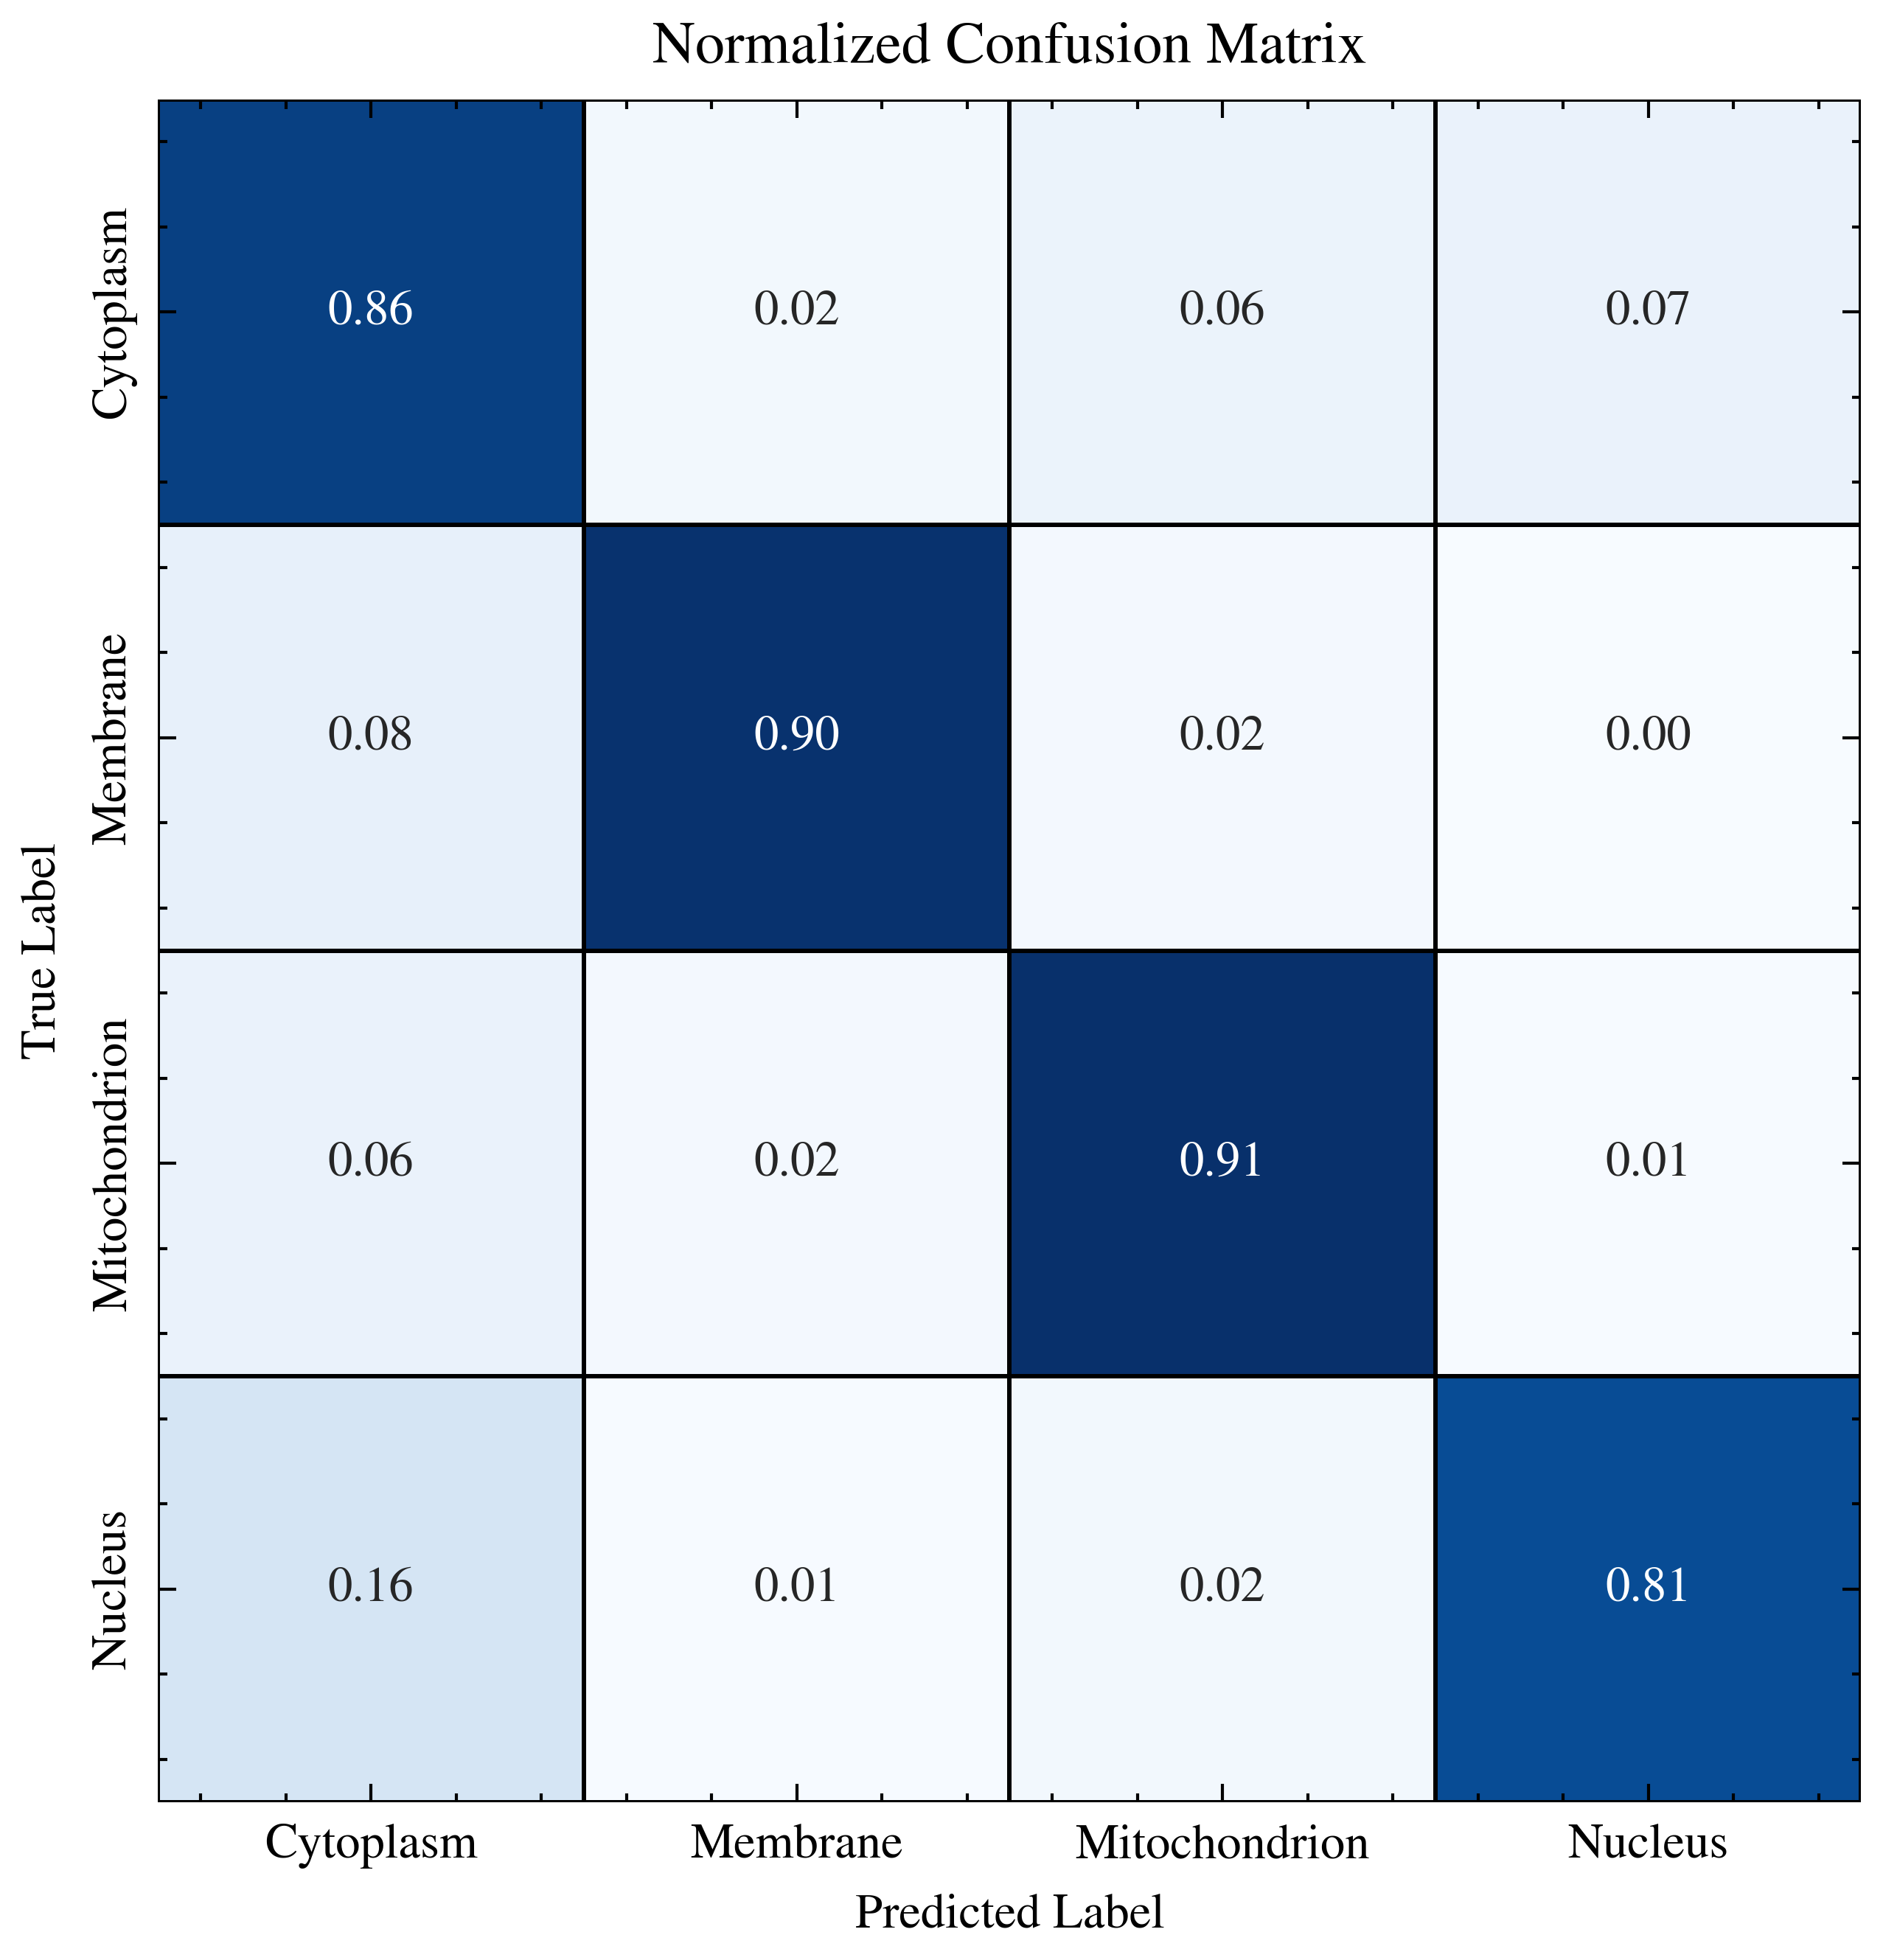


2️⃣  Generating ROC Curves...


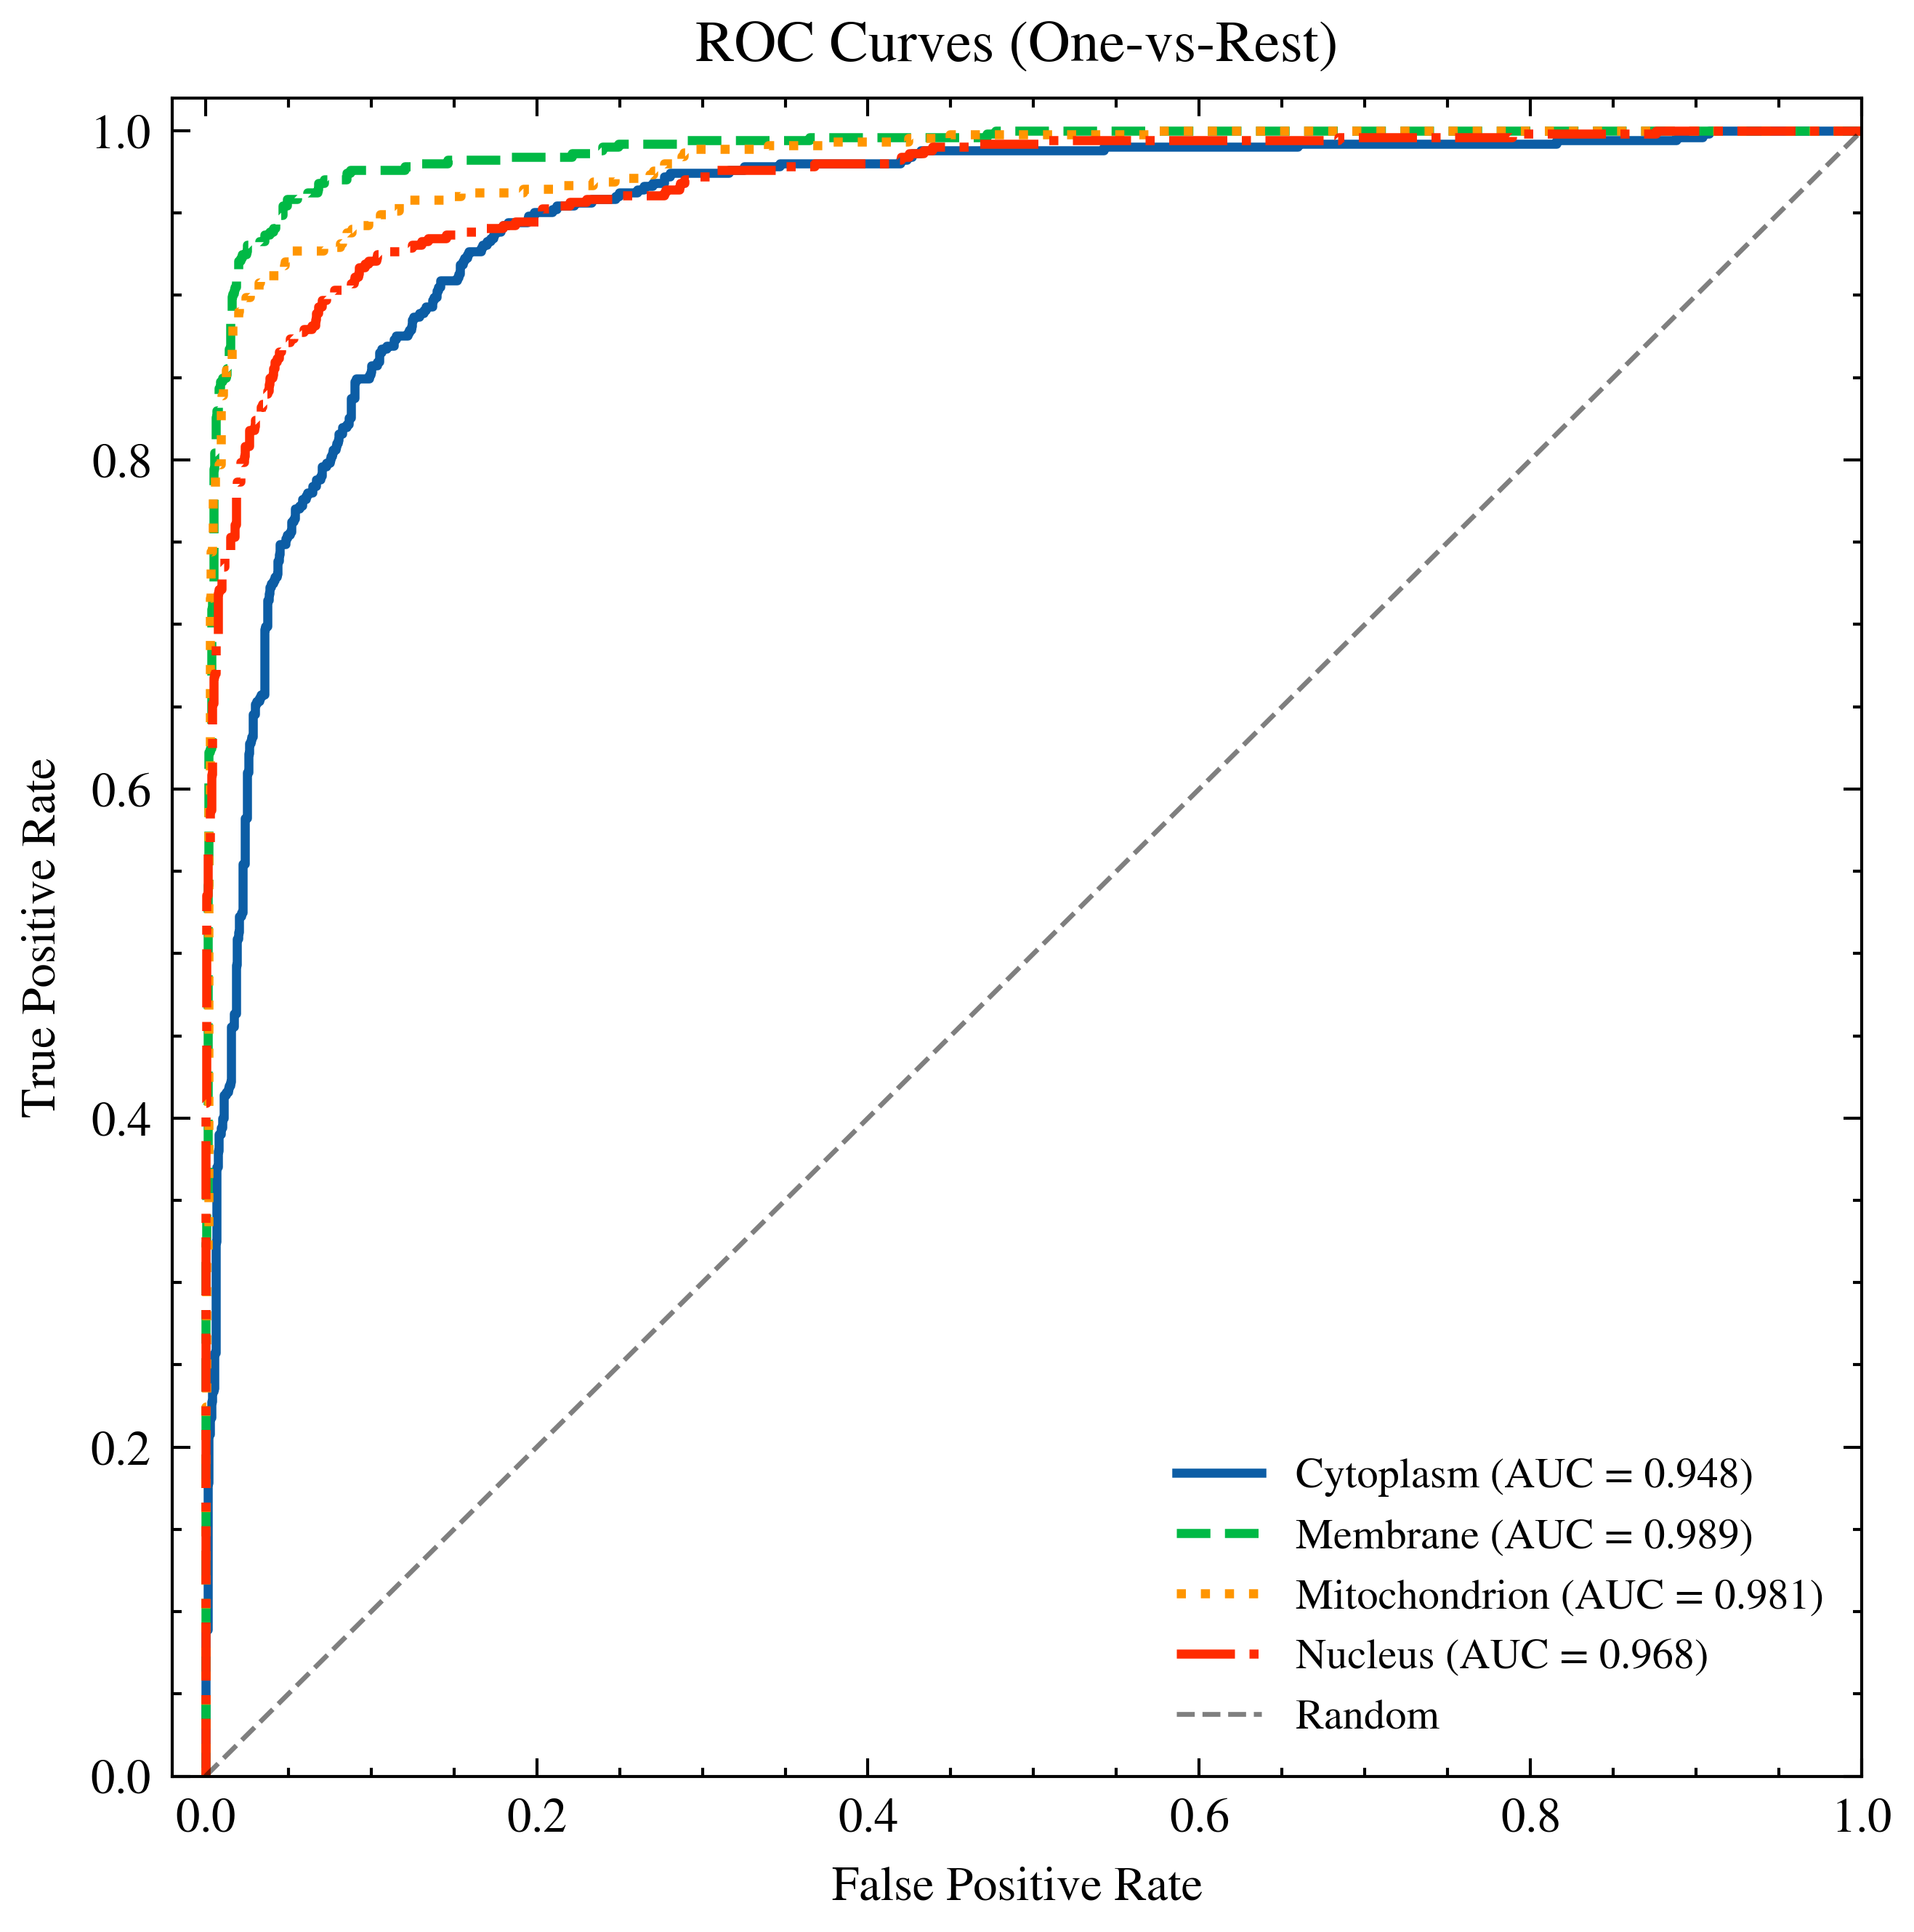


3️⃣  Generating t-SNE Plot...
   -> Subsampling to 500 points...
   -> Extracting features (Manual Batching)...
   -> Clearing model from RAM...
   -> Running t-SNE...


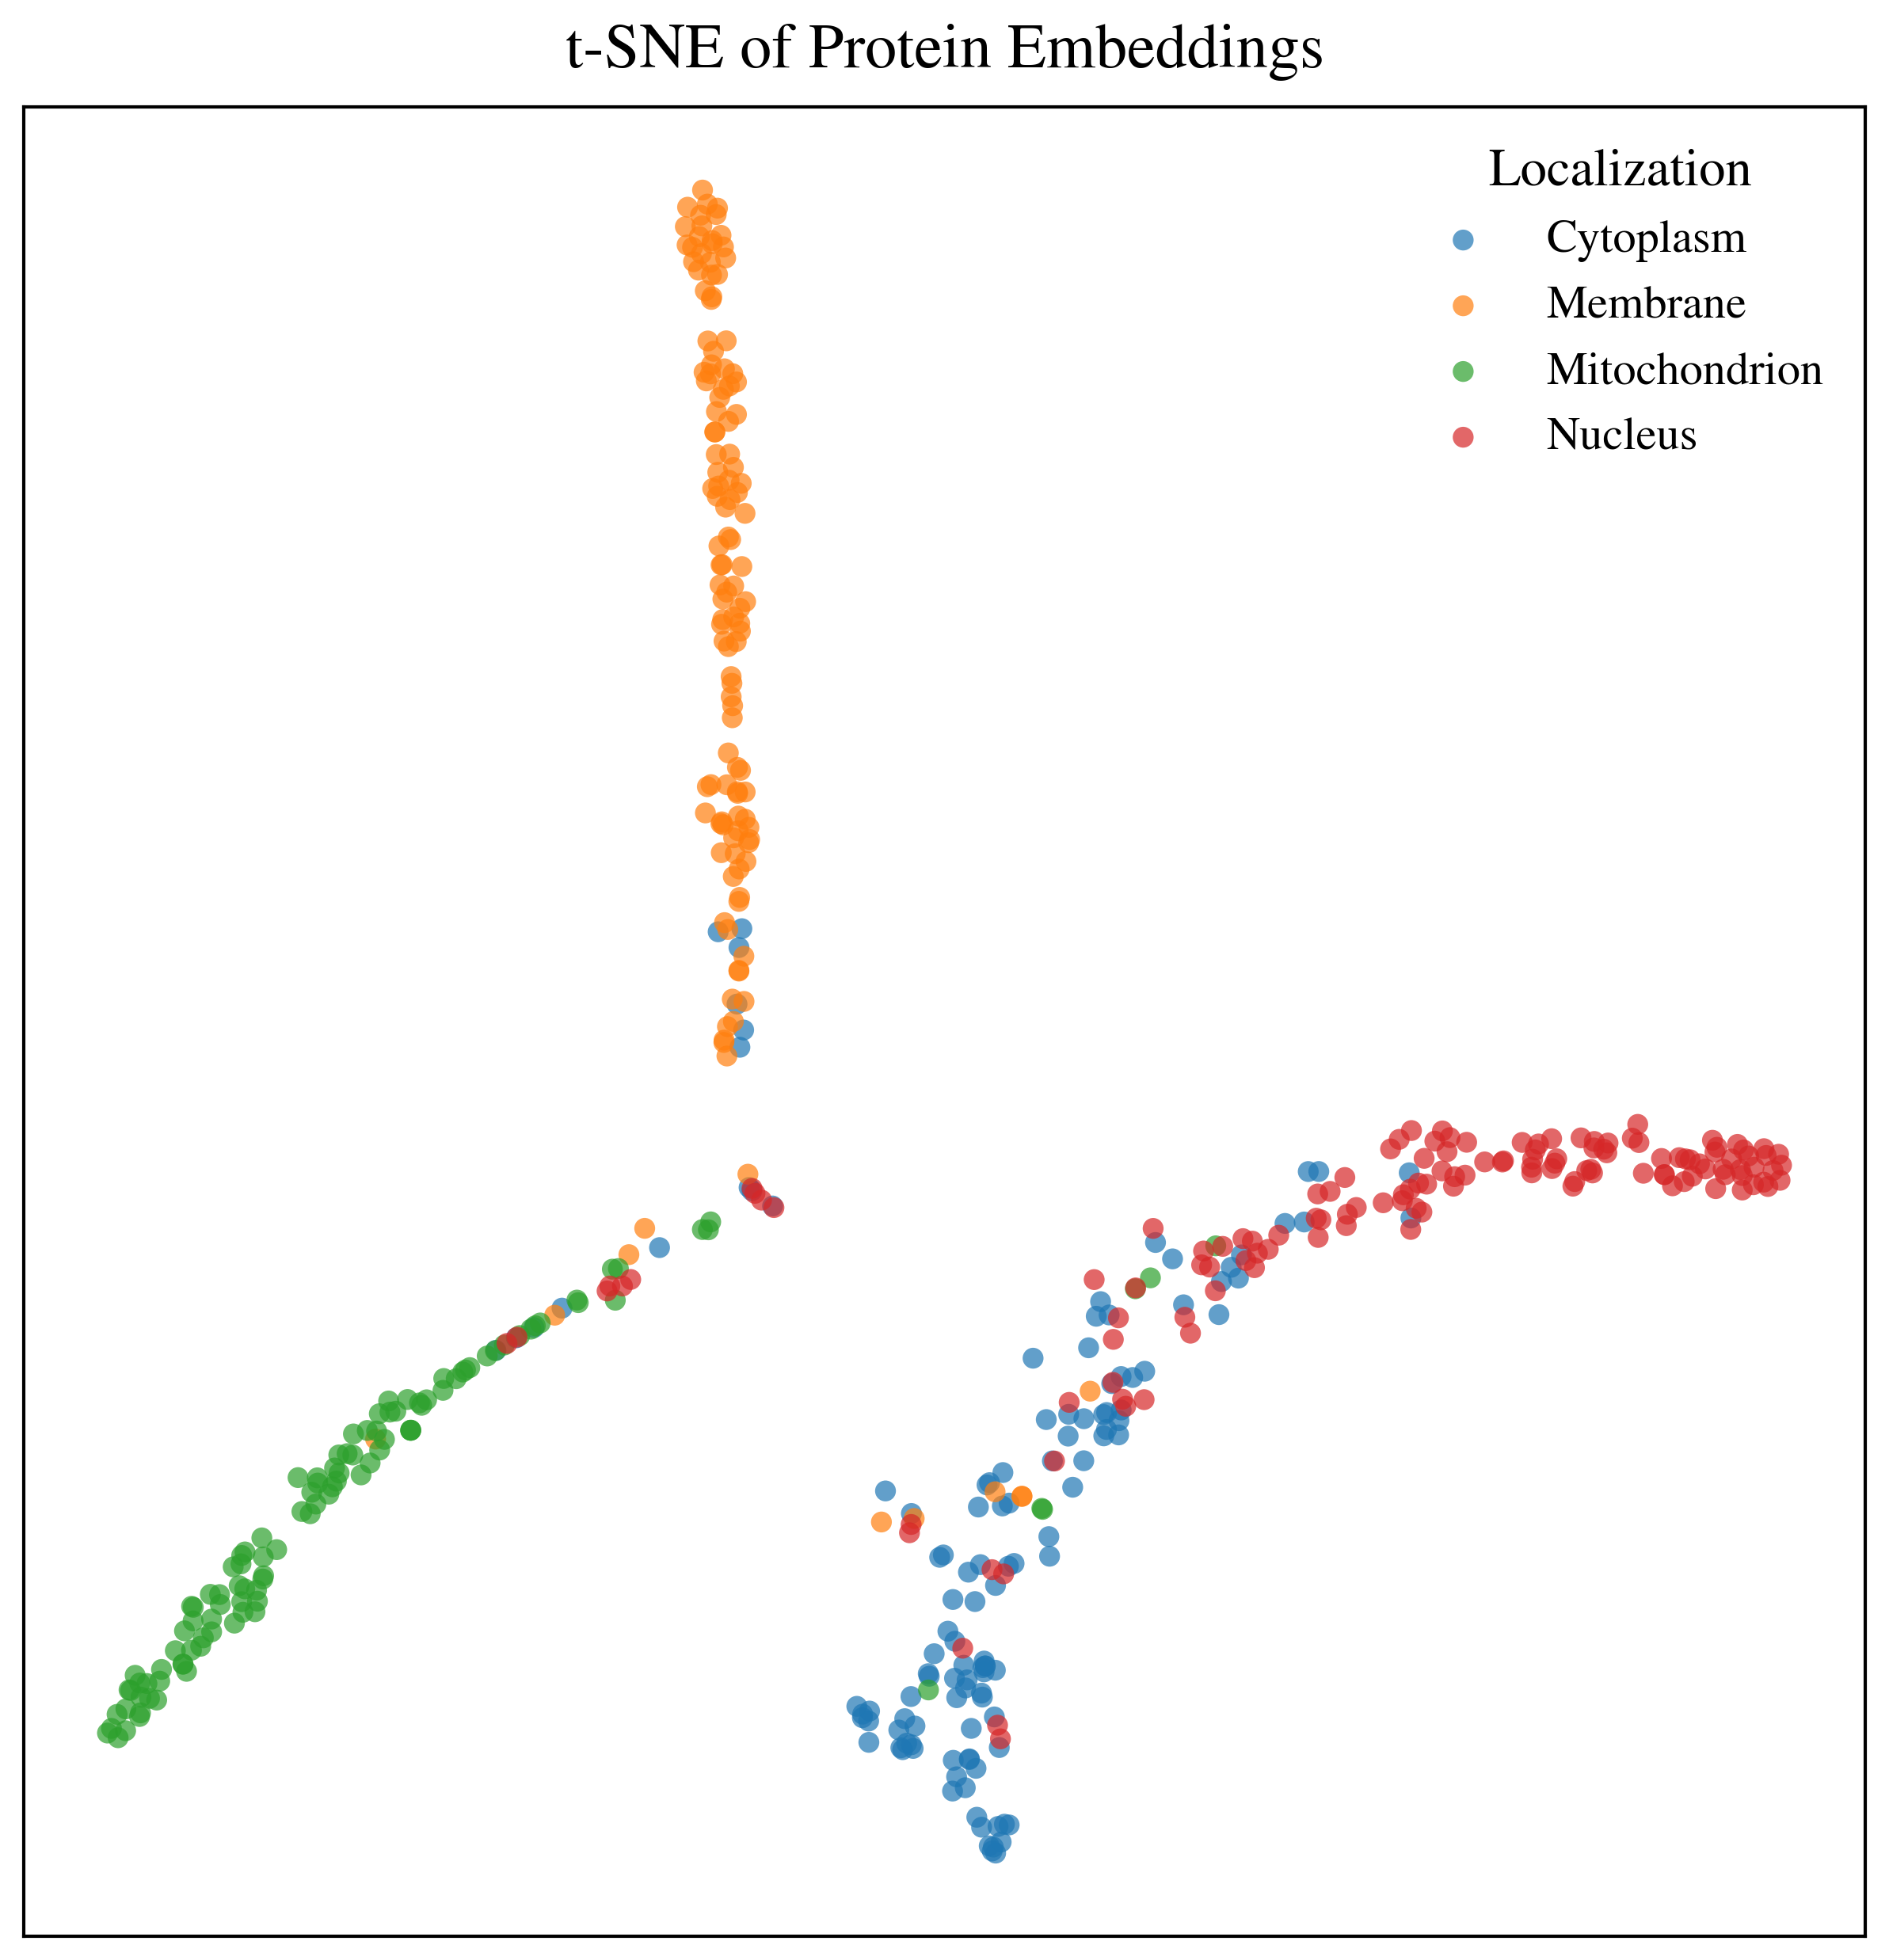


4️⃣  Generating Attention Maps...
   🏆 Cytoplasm: sp|P02406|RL28_YEAST (0.8696)


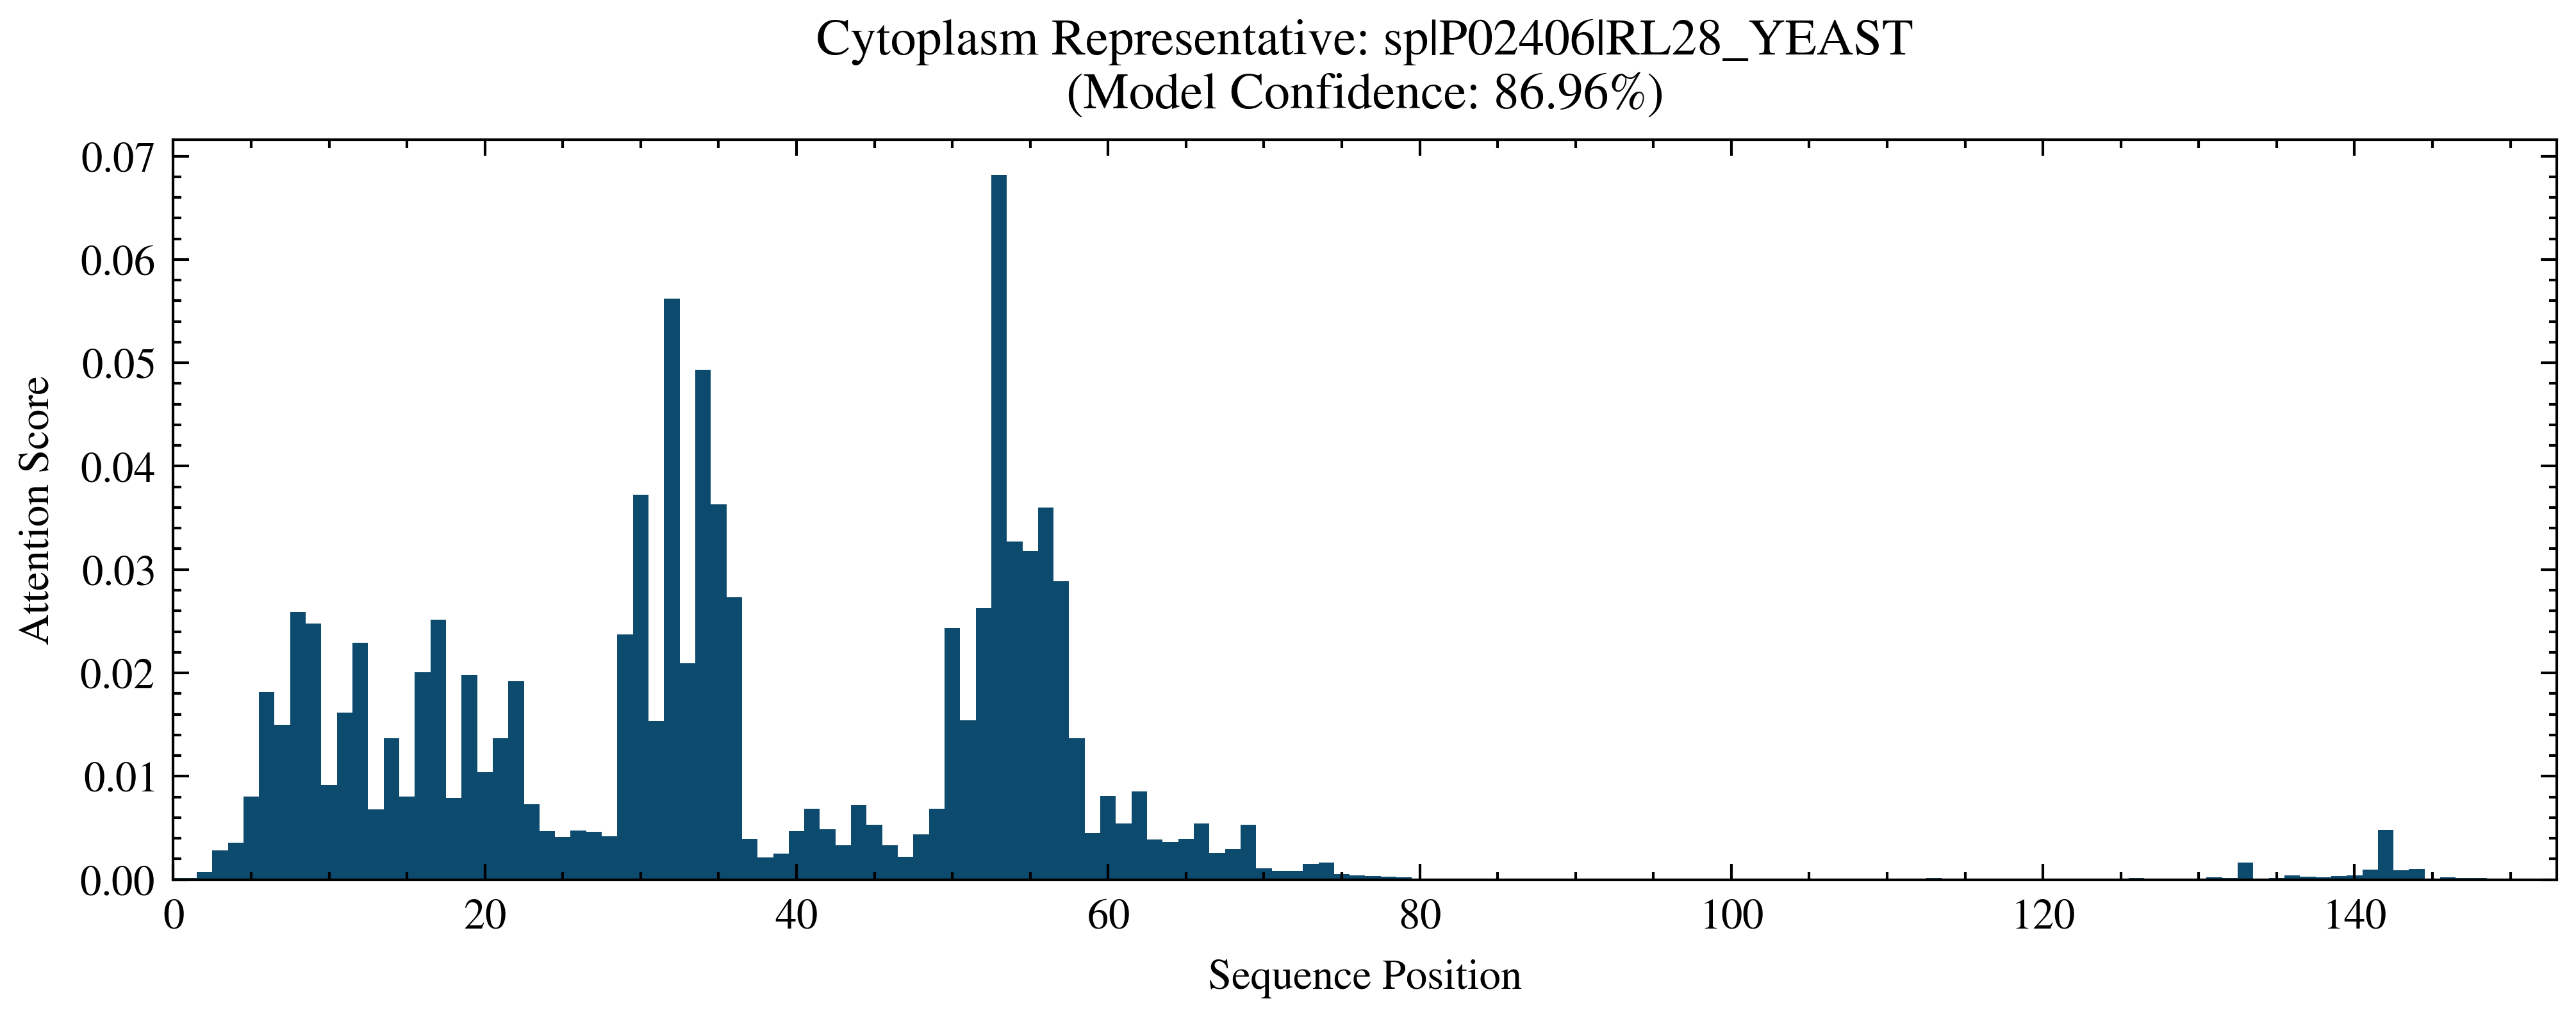

   🏆 Membrane: sp|P16573|CEAM1_RAT (0.8682)


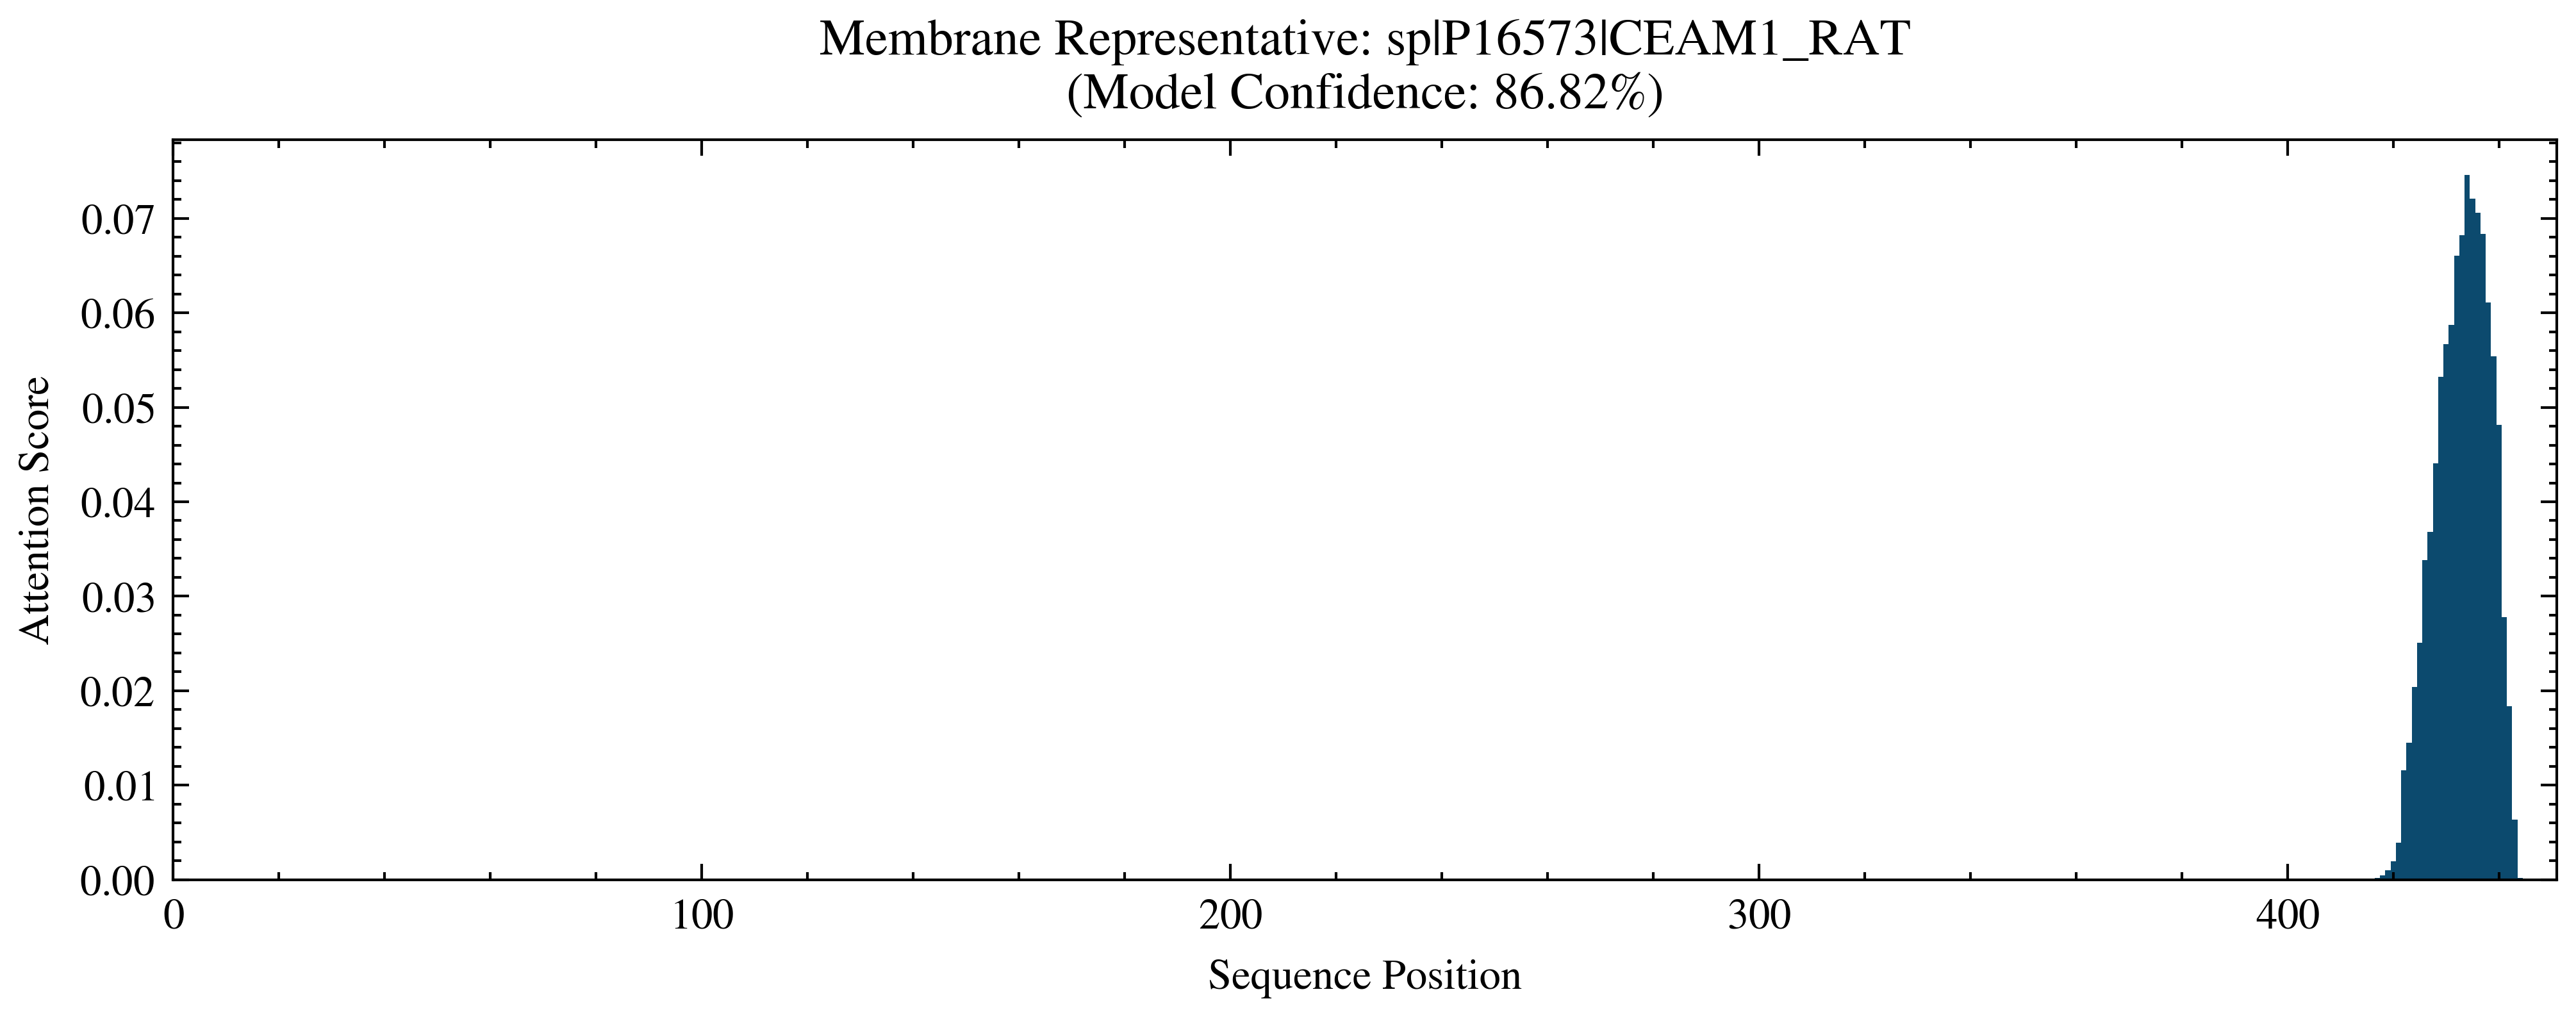

   🏆 Mitochondrion: sp|Q99LC3|NDUAA_MOUSE (0.9097)


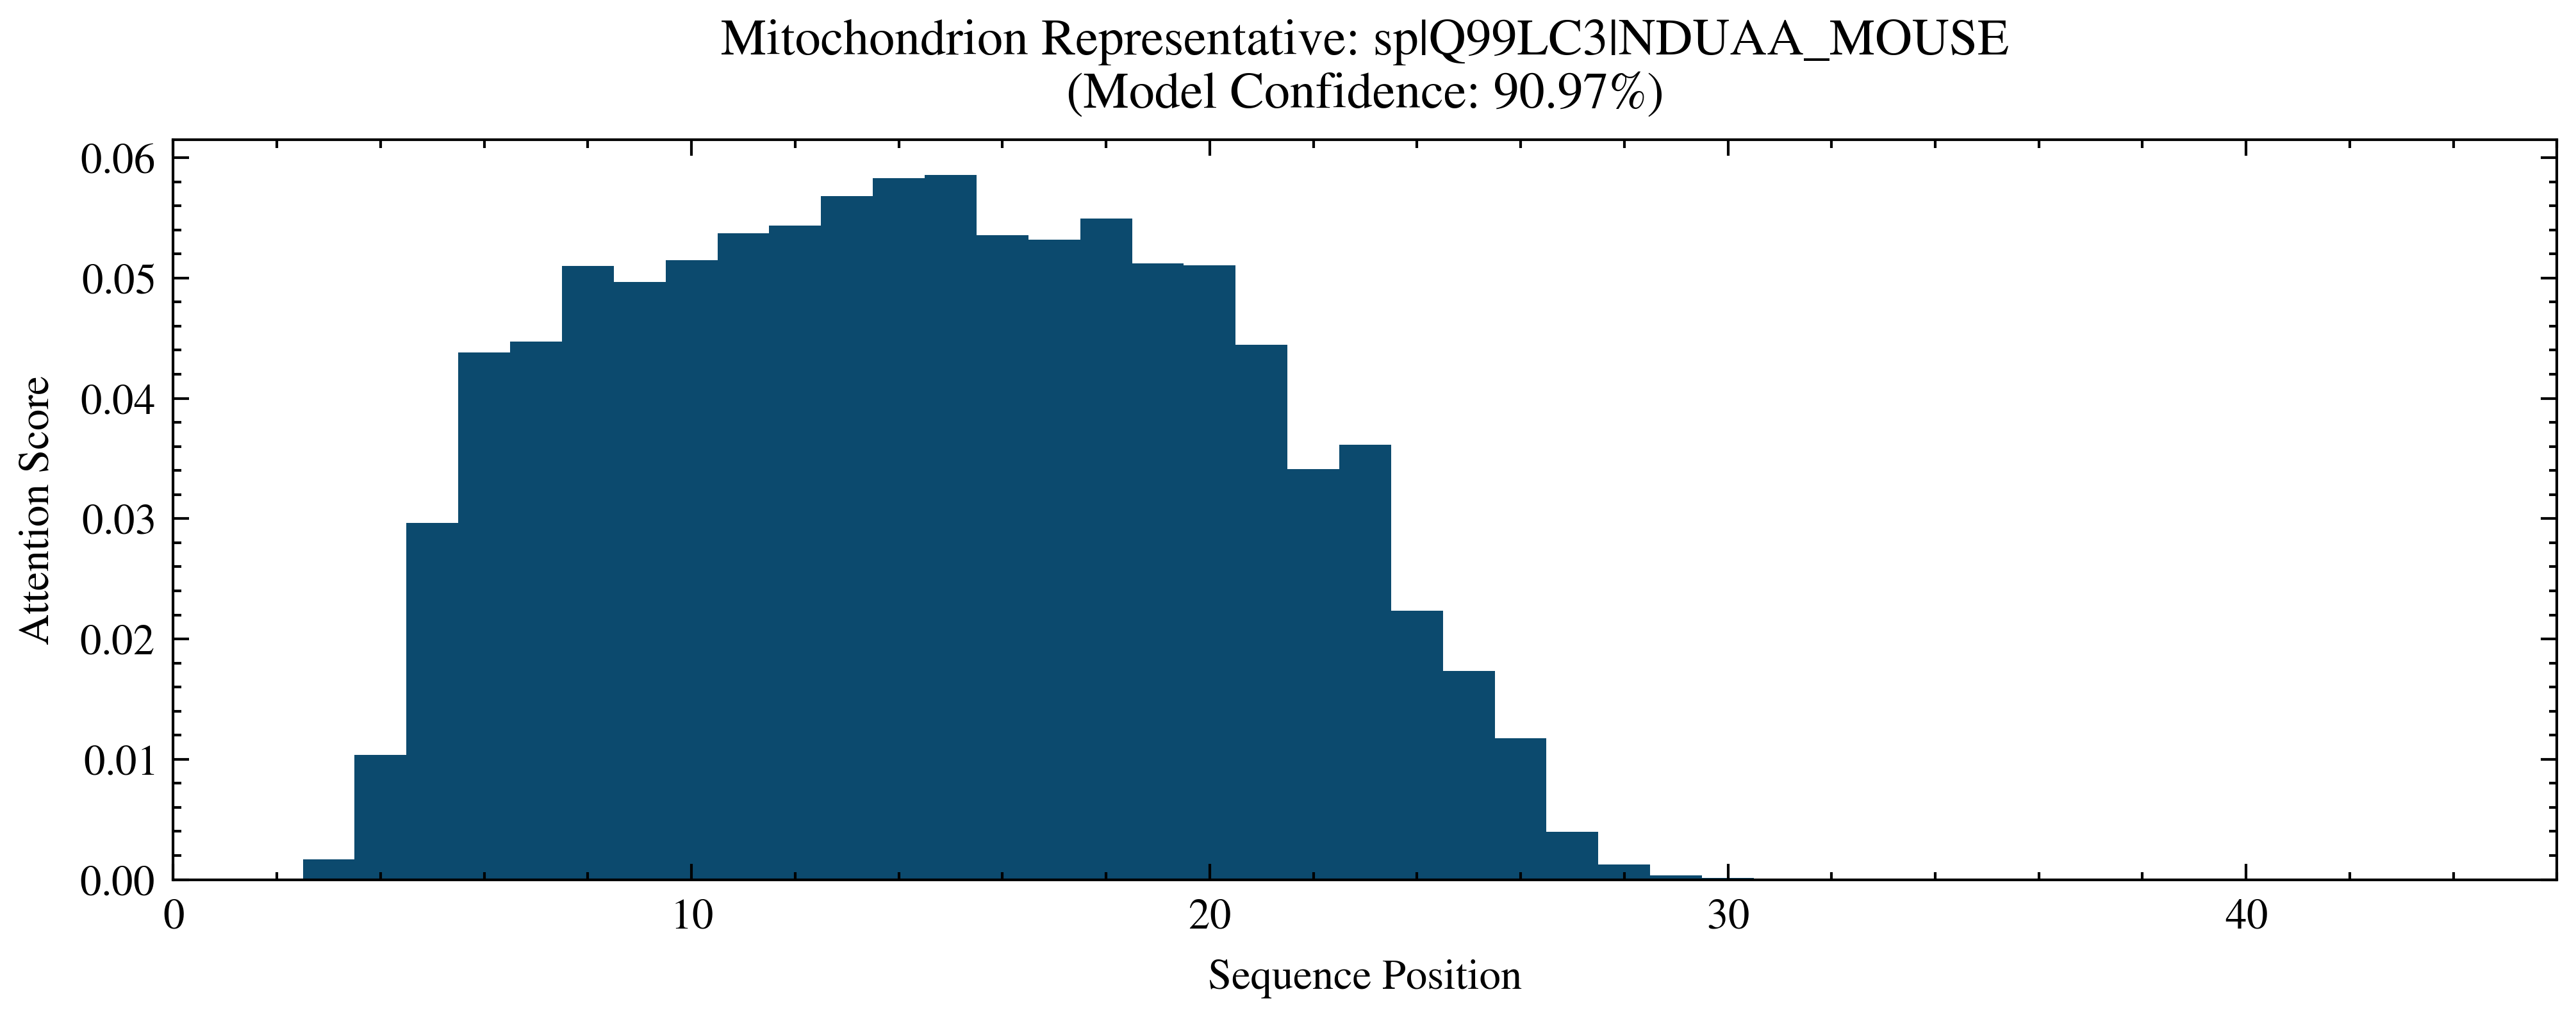

   🏆 Nucleus: sp|P20264|PO3F3_HUMAN (0.8634)


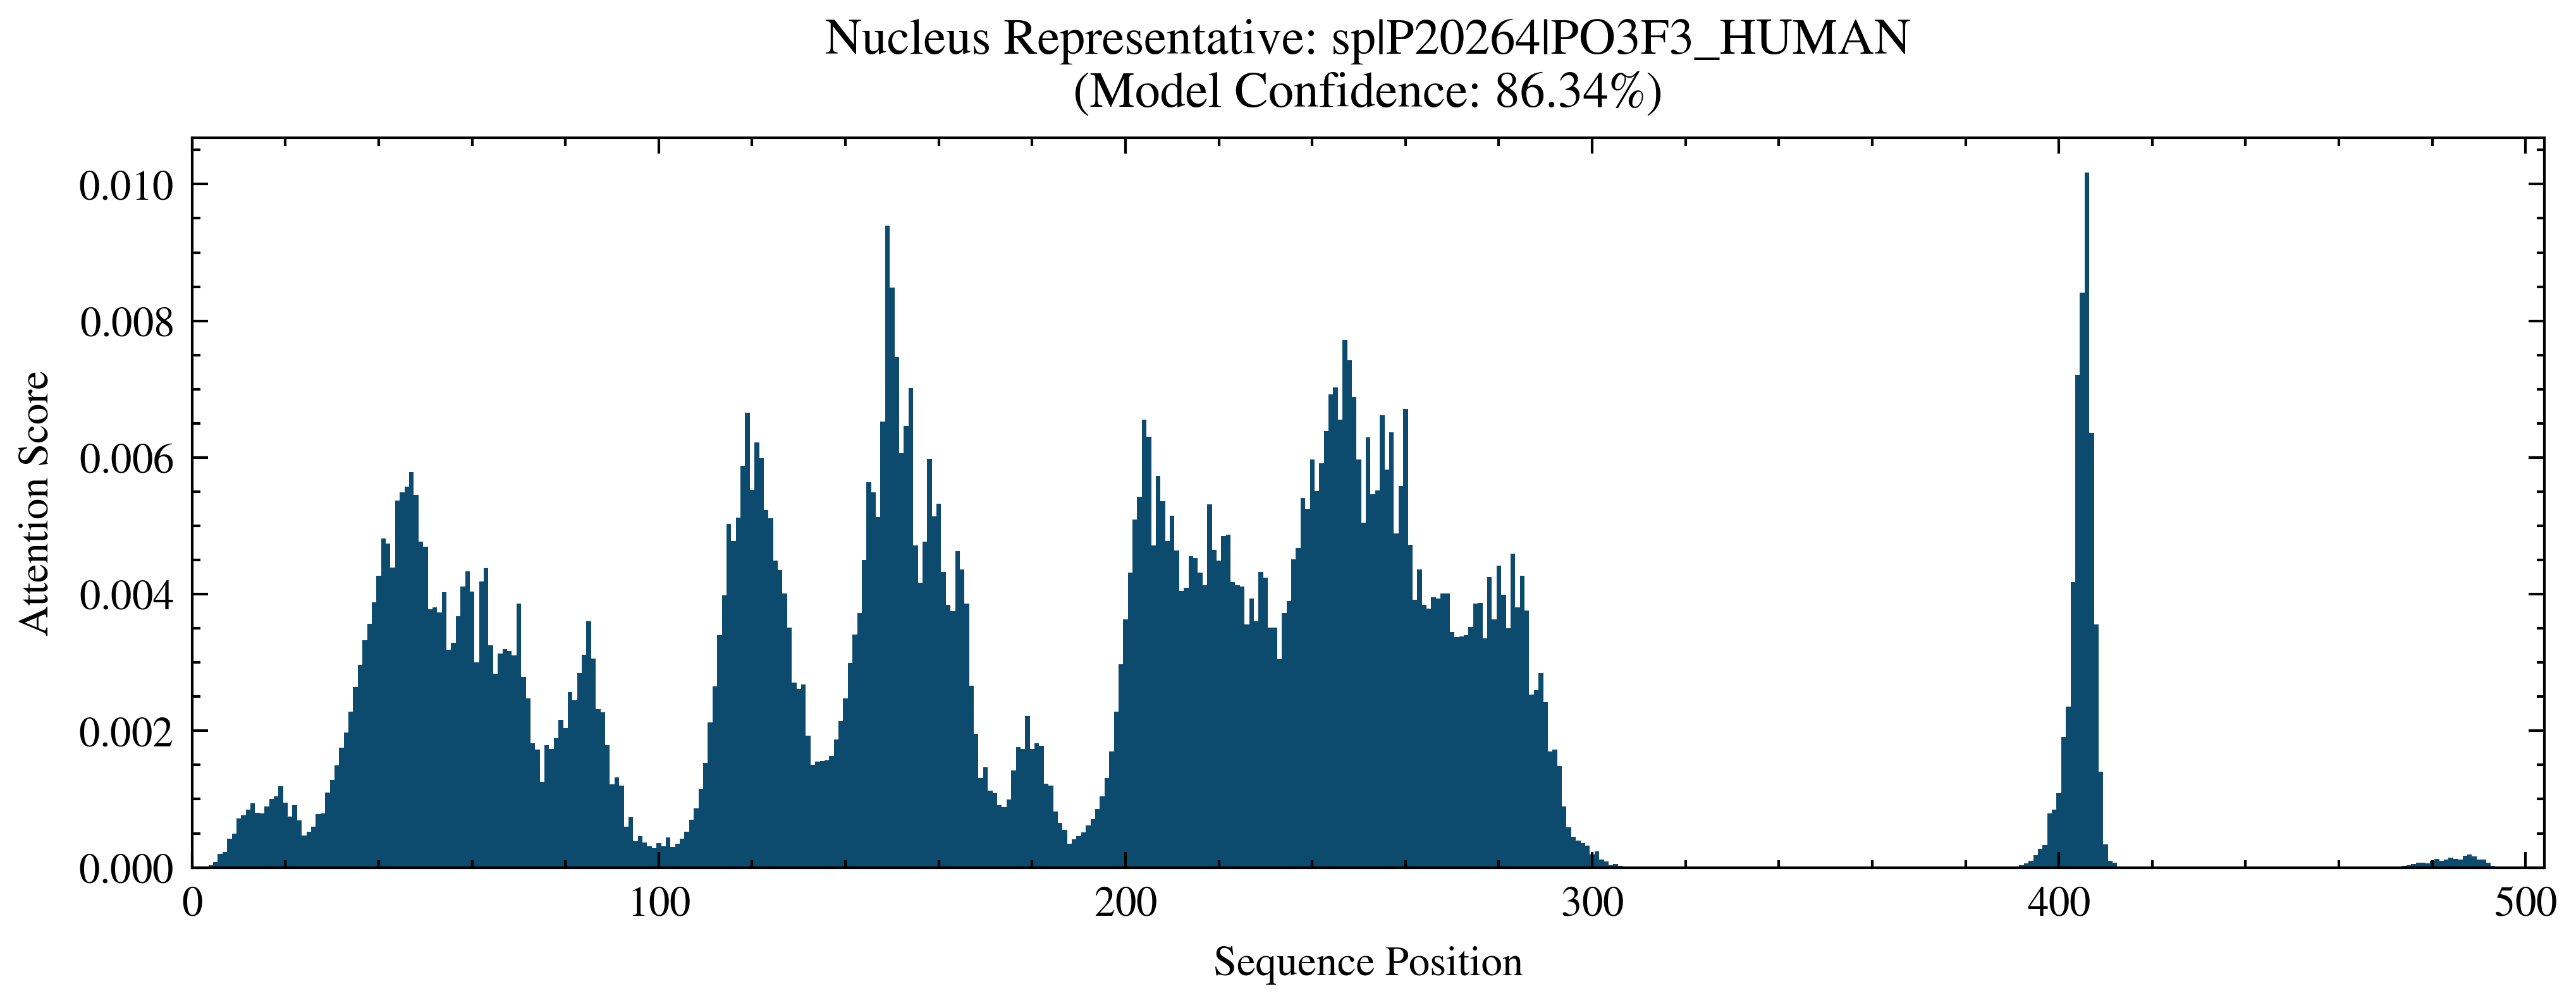


✅ All Figures saved in: /content/drive/MyDrive/BIOINFORMATICS_Protein_Project_v8_CLEANED/figures


In [ ]:

import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize
from sklearn.manifold import TSNE
from tensorflow.keras.models import Model
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers, backend as K
import scienceplots
import gc

# 1. FORCE CLEANUP
K.clear_session()
gc.collect()

print("\n" + "="*70)
print(" GENERATING SCIENTIFIC VISUALIZATIONS (NUCLEAR SAFETY MODE)")
print("="*70)

SAVE_DIR = os.path.join(BASE_DIR, "figures")
os.makedirs(SAVE_DIR, exist_ok=True)
plt.style.use(['science', 'ieee', 'no-latex'])

# ---------------------------------------------------------
# 2. VERIFIED ARCHITECTURE DEFINITION
# ---------------------------------------------------------
def _viz_build_model(input_shape, num_classes):
    # EXACT COPY OF PART 6 ARCHITECTURE
    inputs = layers.Input(shape=input_shape, dtype='float32', name='input_sequence')

    # Masking Logic
    mask = layers.Lambda(lambda x: K.cast(K.any(K.not_equal(x, 0.0), axis=-1), 'float32'))(inputs)
    masked_input = layers.Masking(mask_value=0.0)(inputs)

    # Bi-LSTM (256 units, 0.3 dropout)
    x = layers.Bidirectional(layers.LSTM(256, return_sequences=True, dropout=0.3))(masked_input)

    # Attention (64 units, tanh)
    att_scores = layers.Dense(64, activation='tanh')(x)
    att_logits = layers.Dense(1)(att_scores)
    att_logits = layers.Flatten()(att_logits)
    att_logits_masked = layers.Add()([att_logits, layers.Lambda(lambda m: (1.0 - m) * -1e9)(mask)])
    att_weights = layers.Softmax(axis=1, name='attention_weights')(att_logits_masked)

    att_weights_expanded = layers.Reshape((input_shape[0], 1))(att_weights)
    context = layers.Multiply()([x, att_weights_expanded])
    context_vector = layers.Lambda(lambda z: K.sum(z, axis=1))(context)

    # Classification (512 -> 256, L2=0.01)
    x = layers.Dense(512, activation='relu', kernel_regularizer=regularizers.l2(0.01))(context_vector)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.01))(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation='softmax', dtype='float32')(x)

    model = models.Model(inputs=inputs, outputs=outputs)
    return model

# ---------------------------------------------------------
# 3. MANUAL BATCH PREDICTION (NO model.predict)
# ---------------------------------------------------------
print("\n Generating Predictions (Manual Batching)...")

fold_dir = os.path.join(BASE_DIR, "fold_checkpoints")
model_files = sorted([os.path.join(fold_dir, f) for f in os.listdir(fold_dir) if f.endswith('.keras')])

if not model_files:
    raise FileNotFoundError(" No models found. Run Part 7 first.")

# Prepare arrays
y_prob = np.zeros((len(X_test_mem), len(le.classes_)), dtype='float32')
best_model_path = model_files[0]
SAFE_BATCH_SIZE = 16 # Tiny batch size to guarantee no crash

for i, m_path in enumerate(model_files):
    print(f"   -> Fold {i+1}...", end=" ")

    # Load Model
    model = _viz_build_model((config.MAX_LEN, config.EMBEDDING_DIM), len(le.classes_))
    model.load_weights(m_path)

    # MANUAL LOOP: Avoids Keras pre-fetching memory spikes
    for start_idx in range(0, len(X_test_mem), SAFE_BATCH_SIZE):
        end_idx = min(start_idx + SAFE_BATCH_SIZE, len(X_test_mem))
        batch_x = X_test_mem[start_idx:end_idx] # Load tiny slice
        batch_pred = model(batch_x, training=False).numpy() # Direct call
        y_prob[start_idx:end_idx] += batch_pred

    if i == 0: best_model_path = m_path

    # Cleanup
    K.clear_session()
    del model
    gc.collect()
    print("Done.")

y_prob /= len(model_files)
y_pred = np.argmax(y_prob, axis=1)

# =======================================================
# FIGURE 1: CONFUSION MATRIX
# =======================================================
print("\n1️  Generating Confusion Matrix...")
cm = confusion_matrix(y_test, y_pred)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(5, 5))
sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_, cbar=False,
            square=True, linewidths=0.5, linecolor='black', annot_kws={"size": 8})
plt.xlabel('Predicted Label'); plt.ylabel('True Label'); plt.title('Normalized Confusion Matrix')
plt.savefig(os.path.join(SAVE_DIR, 'Figure2_ConfusionMatrix.png'), dpi=600, bbox_inches='tight')
plt.show()

# =======================================================
# FIGURE 2: ROC CURVES
# =======================================================
print("\n2️  Generating ROC Curves...")
y_test_bin = label_binarize(y_test, classes=range(len(le.classes_)))
n_classes = y_test_bin.shape[1]

plt.figure(figsize=(5, 5))
colors = ['#0C5DA5', '#00B945', '#FF9500', '#FF2C00']
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=colors[i % len(colors)], lw=1.5,
             label=f'{le.classes_[i]} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=0.8, alpha=0.5, label='Random')
plt.xlim([-0.02, 1.0]); plt.ylim([0.0, 1.02])
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate'); plt.title('ROC Curves (One-vs-Rest)')
plt.legend(loc="lower right", fontsize=7)
plt.savefig(os.path.join(SAVE_DIR, 'Figure3_ROC.png'), dpi=600, bbox_inches='tight')
plt.show()

# =======================================================
# FIGURE 3: t-SNE CLUSTERING (SAFE MANUAL BATCHING)
# =======================================================
print("\n3️  Generating t-SNE Plot...")

model = _viz_build_model((config.MAX_LEN, config.EMBEDDING_DIM), len(le.classes_))
model.load_weights(best_model_path)

try:
    dense_layer = None
    for layer in model.layers:
        if isinstance(layer, tf.keras.layers.Dense) and layer.units == 256:
            dense_layer = layer
            break

    if dense_layer:
        feature_model = Model(inputs=model.input, outputs=dense_layer.output)


        MAX_SAMPLES = 500
        print(f"   -> Subsampling to {MAX_SAMPLES} points...")

        if len(X_test_mem) > MAX_SAMPLES:
            indices = np.random.choice(len(X_test_mem), MAX_SAMPLES, replace=False)
            y_subset = y_test[indices]
        else:
            indices = np.arange(len(X_test_mem))
            y_subset = y_test

        print("   -> Extracting features (Manual Batching)...")
        X_features = np.zeros((len(indices), 256), dtype='float32')

        for i in range(0, len(indices), SAFE_BATCH_SIZE):
            batch_idx = indices[i : i + SAFE_BATCH_SIZE]
            batch_input = X_test_mem[batch_idx] # Tiny load
            batch_out = feature_model(batch_input, training=False).numpy()
            X_features[i : i + SAFE_BATCH_SIZE] = batch_out

        print("   -> Clearing model from RAM...")
        del model; del feature_model
        K.clear_session(); gc.collect()

        print("   -> Running t-SNE...")
        tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
        X_embedded = tsne.fit_transform(X_features)

        # Plot
        plt.figure(figsize=(5, 5))
        scatter_colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
        for i, class_name in enumerate(le.classes_):
            mask = (y_subset == i)
            plt.scatter(X_embedded[mask, 0], X_embedded[mask, 1], label=class_name,
                        s=10, alpha=0.7, c=scatter_colors[i % len(scatter_colors)], edgecolors='none')

        plt.title('t-SNE of Protein Embeddings'); plt.xticks([]); plt.yticks([])
        plt.legend(title='Localization', fontsize=7, loc='best')
        plt.savefig(os.path.join(SAVE_DIR, 'Figure5_tSNE_Clusters.png'), dpi=600, bbox_inches='tight')
        plt.show()
    else:
        print(" Dense(256) layer not found.")

except Exception as e:
    print(f" t-SNE Error: {e}")

# =======================================================
# FIGURE 4: ATTENTION MAPS
# =======================================================
print("\n4️  Generating Attention Maps...")

model = _viz_build_model((config.MAX_LEN, config.EMBEDDING_DIM), len(le.classes_))
model.load_weights(best_model_path)

def plot_attention_auto(seq_data, pid, class_name, confidence):
    att_model = Model(inputs=model.input, outputs=model.get_layer('attention_weights').output)
    # Direct call, no .predict
    att = att_model(seq_data[np.newaxis, ...], training=False).numpy()[0]

    if np.any(att > 1e-6): valid_len = np.where(att > 1e-6)[0][-1] + 5
    else: valid_len = len(att)
    att = att[:valid_len]

    plt.figure(figsize=(8, 2.5))
    plt.bar(range(len(att)), att, color='#0C4A6E', width=1.0)
    plt.xlabel('Sequence Position'); plt.ylabel('Attention Score')
    plt.title(f'{class_name} Representative: {pid}\n(Model Confidence: {confidence:.2%})')
    plt.xlim(0, len(att))
    plt.savefig(os.path.join(SAVE_DIR, f"Figure4_Best_{class_name}.png"), dpi=600, bbox_inches='tight')
    plt.show()

for class_name in le.classes_:
    class_idx = le.transform([class_name])[0]
    true_indices = np.where(y_test == class_idx)[0]
    best_local_idx = np.argmax(y_prob[true_indices, class_idx])
    best_global_idx = true_indices[best_local_idx]

    pid = str(test_ids[best_global_idx])
    confidence = y_prob[best_global_idx, class_idx]
    seq_data = X_test_mem[best_global_idx].astype('float32') if isinstance(X_test_mem, np.memmap) else X_test_mem[best_global_idx]

    print(f"   🏆 {class_name}: {pid} ({confidence:.4f})")
    plot_attention_auto(seq_data, pid, class_name, confidence)

print(f"\n✅ All Figures saved in: {SAVE_DIR}")

In [ ]:

from sklearn.metrics import accuracy_score, matthews_corrcoef
print(f"✅ ENSEMBLE TEST ACCURACY: {accuracy_score(y_test, y_pred):.4f}")
print(f"✅ ENSEMBLE TEST MCC:      {matthews_corrcoef(y_test, y_pred):.4f}")

✅ ENSEMBLE TEST ACCURACY: 0.8681
✅ ENSEMBLE TEST MCC:      0.8254


In [ ]:
from scipy.interpolate import interp1d

print("\n" + "="*50)
print("SENSITIVITY AT 95% SPECIFICITY (5% FPR)")
print("="*50)

for i, class_name in enumerate(le.classes_):
    # Calculate ROC curve
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])

    # Create an interpolation function (FPR -> TPR)
    # We want to know: What is TPR when FPR is 0.05?
    f = interp1d(fpr, tpr)
    sens_at_95_spec = f(0.05)

    print(f"{class_name:<15}: {sens_at_95_spec:.2%}")

print("="*50)


SENSITIVITY AT 95% SPECIFICITY (5% FPR)
Cytoplasm      : 75.45%
Membrane       : 95.85%
Mitochondrion  : 92.07%
Nucleus        : 87.15%


# PART 10.7: GENERATE MULocDeep SUBSET

In [ ]:
import pandas as pd
import os
from sklearn.model_selection import train_test_split


def generate_muloc_subset():
    print(" Creating 200-sequence subset for MULocDeep...")

    # 1. Load the Benchmark Results (Matches the DeepLoc FASTA)

    input_csv = os.path.join(BASE_DIR, "scientific_benchmark_results.csv")

    if not os.path.exists(input_csv):
        print(" Error: 'scientific_benchmark_results.csv' not found. Run Part 10 first.")
        return

    df = pd.read_csv(input_csv)
    print(f"   Original Benchmark Size: {len(df)} sequences")

    # 2. Stratified Sampling (Downsample to exactly 200)

    if len(df) > 200:
        subset_df, _ = train_test_split(
            df,
            train_size=200,
            stratify=df['label'],
            random_state=42
        )
    else:
        subset_df = df.copy()
        print("    Dataset < 200, using all sequences.")

    # 3. Save FASTA for MULocDeep Upload

    fasta_path = os.path.join(BASE_DIR, "new_to_upload_to_MULocDeep.fasta")
    with open(fasta_path, "w") as f:
        for idx, row in subset_df.iterrows():

            f.write(f">{idx}|{row['label']}\n{row['sequence']}\n")

    # 4. Save the "Answer Key" (True Labels + YOUR Model's Predictions)

    metadata_path = os.path.join(BASE_DIR, "muloc_subset_metadata.csv")
    subset_df.to_csv(metadata_path, index=True) # Keep index to match FASTA headers

    print(f"\n✅ FILES CREATED for MULocDeep Comparison:")
    print(f"   1. Upload this file to MULocDeep:   {fasta_path}")
    print(f"   2. Metadata (Your Predictions):     {metadata_path}")
    print(f"   Subset Size: {len(subset_df)}")

# Run it
generate_muloc_subset()

✂️ Creating 200-sequence subset for MULocDeep...
   Original Benchmark Size: 86 sequences
   ⚠️ Dataset < 200, using all sequences.

✅ FILES CREATED for MULocDeep Comparison:
   1. Upload this file to MULocDeep:   /content/drive/MyDrive/BIOINFORMATICS_Protein_Project_v8_CLEANED/new_to_upload_to_MULocDeep.fasta
   2. Metadata (Your Predictions):     /content/drive/MyDrive/BIOINFORMATICS_Protein_Project_v8_CLEANED/muloc_subset_metadata.csv
   Subset Size: 86


In [ ]:
import pandas as pd
import os
import re
from sklearn.metrics import accuracy_score, matthews_corrcoef

def parse_and_compare_muloc(muloc_filename="muloc_results.txt"):
    print(f"⚔️ Parsing Custom MULocDeep File: {muloc_filename}")

    # 1. Load Your Ground Truth (The 200 subset)

    meta_path = os.path.join(BASE_DIR, "muloc_subset_metadata.csv")
    if not os.path.exists(meta_path):
        print(" Error: 'muloc_subset_metadata.csv' not found. You must run Part 10.7 first.")
        return

    # Load ground truth (Index is the numeric ID: 0, 1, 2...)
    gt_df = pd.read_csv(meta_path, index_col=0)
    print(f"   Loaded {len(gt_df)} ground truth records.")

    # 2. Parse the Text File Line-by-Line
    muloc_path = os.path.join(BASE_DIR, muloc_filename)
    if not os.path.exists(muloc_path):
        print(f" Error: '{muloc_filename}' not found.")
        return

    comparison_list = []

    with open(muloc_path, 'r') as f:
        for line in f:
            line = line.strip()
            if not line or not line.startswith(">"): continue

            try:
                # --- PARSE ID ---
                # Example: ">31|Nucleus:	Nucleus:0.99..."
                # We want to extract "31"
                header_part = line.split('\t')[0]  # ">31|Nucleus:"
                id_str = header_part.split('|')[0] # ">31"
                idx = int(id_str.replace('>', '')) # 31

                # --- PARSE PREDICTION ---
                # Example end of line: "...prediction:Nucleus|"
                # We want "Nucleus"
                last_part = line.split('\t')[-1]   # "prediction:Nucleus|"
                if "prediction:" in last_part:
                    pred_raw = last_part.split(':')[1] # "Nucleus|"
                    pred_label = pred_raw.replace('|', '').strip() # "Nucleus"
                else:
                    continue # Skip malformed lines

                # --- MATCH WITH GROUND TRUTH ---
                if idx in gt_df.index:
                    true_label = gt_df.loc[idx, 'true_label']
                    my_pred = gt_df.loc[idx, 'predicted_label']

                    # Store for comparison
                    comparison_list.append({
                        'id': idx,
                        'true': true_label,
                        'me': my_pred,
                        'muloc': pred_label
                    })

            except Exception as e:
                # print(f"Skipping line due to error: {e}")
                continue

    # 3. Compute Metrics
    if not comparison_list:
        print(" No valid matches found! Check your IDs.")
        return

    df = pd.DataFrame(comparison_list)



    print("\n" + "="*60)
    print(f"FINAL HEAD-TO-HEAD (N={len(df)} sequences)")
    print("="*60)
    print(f"{'Metric':<15} | {'Your Model':<12} | {'MULocDeep':<12}")
    print("-" * 60)

    # Accuracy
    my_acc = accuracy_score(df['true'], df['me'])
    mu_acc = accuracy_score(df['true'], df['muloc'])

    # MCC
    my_mcc = matthews_corrcoef(df['true'], df['me'])
    mu_mcc = matthews_corrcoef(df['true'], df['muloc'])

    print(f"{'Accuracy':<15} | {my_acc:.4f}       | {mu_acc:.4f}")
    print(f"{'MCC':<15} | {my_mcc:.4f}       | {mu_mcc:.4f}")
    print("-" * 60)

    # Save comparison to drive for review
    save_path = os.path.join(BASE_DIR, "final_muloc_comparison.csv")
    df.to_csv(save_path, index=False)
    print(f"\n Detailed comparison saved to: {save_path}")

# --- EXECUTE ---
parse_and_compare_muloc("muloc_results.txt")

⚔️ Parsing Custom MULocDeep File: muloc_results.txt
   Loaded 86 ground truth records.

FINAL HEAD-TO-HEAD (N=86 sequences)
Metric          | Your Model   | MULocDeep   
------------------------------------------------------------
Accuracy        | 0.8837       | 0.7791
MCC             | 0.8274       | 0.6817
------------------------------------------------------------

✅ Detailed comparison saved to: /content/drive/MyDrive/BIOINFORMATICS_Protein_Project_v8_CLEANED/final_muloc_comparison.csv


In [ ]:
import pandas as pd
import os
from scipy import stats

def run_muloc_ttest(muloc_filename="muloc_results.txt"):
    print(f" Running Statistical Significance Test against MULocDeep...")

    # 1. LOAD METADATA (Ground Truth & Your Predictions)
    meta_path = os.path.join(BASE_DIR, "muloc_subset_metadata.csv")
    if not os.path.exists(meta_path):
        print(" Error: 'muloc_subset_metadata.csv' missing.")
        return
    gt_df = pd.read_csv(meta_path, index_col=0)

    # 2. LOAD MULOC PREDICTIONS
    muloc_path = os.path.join(BASE_DIR, muloc_filename)
    if not os.path.exists(muloc_path):
        print(f" Error: '{muloc_filename}' missing.")
        return

    # 3. BUILD COMPARISON DATAFRAME
    comparison_data = []
    with open(muloc_path, 'r') as f:
        for line in f:
            line = line.strip()
            if not line or not line.startswith(">"): continue
            try:
                # Parse ID (e.g., ">31|Nucleus..." -> 31)
                idx = int(line.split('\t')[0].split('|')[0].replace('>', ''))

                # Parse Prediction (e.g., "...prediction:Nucleus|" -> Nucleus)
                last_part = line.split('\t')[-1]
                if "prediction:" in last_part:
                    muloc_pred = last_part.split(':')[1].replace('|', '').strip()
                else:
                    continue

                if idx in gt_df.index:
                    comparison_data.append({
                        'true': gt_df.loc[idx, 'true_label'],
                        'me': gt_df.loc[idx, 'predicted_label'],
                        'muloc': muloc_pred
                    })
            except: continue

    if not comparison_data:
        print(" No matching data found.")
        return

    df = pd.DataFrame(comparison_data)

    # 4. PERFORM PAIRED T-TEST
    # Create binary vectors: 1 if correct, 0 if wrong
    my_correct = (df['true'] == df['me']).astype(int)
    muloc_correct = (df['true'] == df['muloc']).astype(int)

    t_stat, p_value = stats.ttest_rel(my_correct, muloc_correct)

    print("\n" + "="*50)
    print("STATISTICAL COMPARISON (Paired T-Test)")
    print("="*50)
    print(f"Your Accuracy:   {my_correct.mean():.4f}")
    print(f"MULoc Accuracy:  {muloc_correct.mean():.4f}")
    print("-" * 50)
    print(f"T-Statistic:     {t_stat:.4f}")
    print(f"P-Value:         {p_value:.4f}")

    if p_value < 0.05:
        print("✅ Result: SIGNIFICANT Difference (p < 0.05)")
    else:
        print("⚠️ Result: NO Significant Difference (p >= 0.05)")
    print("="*50)

# --- RUN IT ---
run_muloc_ttest("muloc_results.txt")

📊 Running Statistical Significance Test against MULocDeep...

STATISTICAL COMPARISON (Paired T-Test)
Your Accuracy:   0.8837
MULoc Accuracy:  0.7791
--------------------------------------------------
T-Statistic:     2.3864
P-Value:         0.0192
✅ Result: SIGNIFICANT Difference (p < 0.05)
